# Расчёт осевого компрессора
## По методике В.С. Бекнева (МВТУ им. Баумана, 1981)
### Комбинированный закон: $D_к = \text{const}$ → $D_{вт} = \text{const}$

**Разделы расчёта:**
1. Техническое задание
2. Предварительные оценки и параметрическая оптимизация
3. Предварительный расчёт проточной части
4. Распределение параметров по ступеням
5. Поступенчатый расчёт по средней линии тока
6. Профилирование решёток


In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 6), 'font.size': 12,
    'axes.grid': True, 'grid.alpha': 0.3
})

# =============================================
# Газодинамические функции идеального газа
# =============================================

def tau_lam(lam, k=1.4):
    return 1.0 - (k - 1.0) / (k + 1.0) * lam**2

def eps_lam(lam, k=1.4):
    t = tau_lam(lam, k)
    if isinstance(t, np.ndarray):
        return np.where(t > 0, np.abs(t)**(1.0/(k-1.0)), 0.0)
    return t**(1.0/(k-1.0)) if t > 0 else 0.0

def q_lam(lam, k=1.4):
    t = tau_lam(lam, k)
    if isinstance(t, np.ndarray):
        return np.where(t > 0, lam * ((k+1)/2)**(1/(k-1)) * np.abs(t)**(1/(k-1)), 0.0)
    if t <= 0:
        return 0.0
    return lam * ((k+1)/2)**(1/(k-1)) * t**(1/(k-1))

def beta_coef(k=1.4):
    return np.sqrt(k) * (2.0/(k+1.0))**((k+1.0)/(2.0*(k-1.0)))

def a_cr_func(T_star, k=1.4, Rg=287.0):
    return np.sqrt(2.0*k/(k+1.0) * Rg * T_star)

# Полиномиальные аппроксимации характеристик ступени (рис. 4)
def eta_stage_poly(ca_bar):
    return -2.454 * ca_bar**2 + 2.401 * ca_bar + 0.296

def HT_bar_poly(ca_bar):
    return -1.015 * ca_bar**2 + 0.408 * ca_bar + 0.344

print("Газодинамические функции загружены.")
print(f"  beta(k=1.4) = {beta_coef():.4f}")
print(f"  q(lam=0.5) = {q_lam(0.5):.4f}")
print(f"  q(lam=1.0) = {q_lam(1.0):.4f}")


Газодинамические функции загружены.
  beta(k=1.4) = 0.6847
  q(lam=0.5) = 0.7091
  q(lam=1.0) = 1.0000


## 1. Техническое задание (исходные данные)

In [59]:
# ================================================
# ИСХОДНЫЕ ДАННЫЕ (из README.md)
# ================================================
G = 58.7            # кг/с — массовый расход
T0_star = 288.0     # К — полная температура на входе
P0_star = 1.013e5   # Па — полное давление на входе
pi_k_star = 18.2    # степень повышения давления
n_rpm = 8600        # об/мин — частота вращения

# Свойства воздуха
k = 1.4
Rg = 287.0          # Дж/(кг·К)
cp = k * Rg / (k - 1.0)  # 1004.5 Дж/(кг·К)

# ================================================
# ПЕРЕКЛЮЧАТЕЛЬ ТИПА КОМПРЕССОРА
# ================================================
# "subsonic"    — дозвуковой   (Mw1 < 0.9,  Uk = 250–350 м/с)
# "transonic"   — околозвуковой (Mw1 = 0.9–1.1, Uk = 360–440 м/с)
# "supersonic"  — сверхзвуковой (Mw1 = 1.1–1.4, Uk = 450–490 м/с)
COMPRESSOR_TYPE = "subsonic"   # <-- ВЫБИРАЙТЕ ЗДЕСЬ

# Параметры ограничений в зависимости от типа
_type_params = {
    "subsonic":   {"Mw1_max": 0.90, "Uk_range": (200, 350), "Z_max": 25, "label": "Дозвуковой"},
    "transonic":  {"Mw1_max": 1.10, "Uk_range": (360, 440), "Z_max": 16, "label": "Околозвуковой"},
    "supersonic": {"Mw1_max": 1.40, "Uk_range": (450, 490), "Z_max": 14, "label": "Сверхзвуковой"},
}
assert COMPRESSOR_TYPE in _type_params, f"Неизвестный тип: {COMPRESSOR_TYPE}"

Mw1_LIMIT = _type_params[COMPRESSOR_TYPE]["Mw1_max"]
Uk_RANGE  = _type_params[COMPRESSOR_TYPE]["Uk_range"]
Z_MAX     = _type_params[COMPRESSOR_TYPE]["Z_max"]
TYPE_LABEL = _type_params[COMPRESSOR_TYPE]["label"]

# ================================================
# ФОРМА ПРОТОЧНОЙ ЧАСТИ
# ================================================
# "dk_const"  — Dk=const на всех ступенях
# "combined"  — Dk=const, затем Dvt=const (переключение при h < H_MIN или d_bar >= D_BAR_MAX)
FLOW_PATH = "combined"   # <-- ВЫБИРАЙТЕ ЗДЕСЬ

H_MIN_MM = 15.0       # мм — минимальная высота лопатки (порог переключения)
D_BAR_MAX = 0.92      # макс. относительный диаметр втулки (порог переключения)

# Убрать последнюю ступень (True — Z уменьшается на 1)
REMOVE_LAST_STAGE = False

# Коэффициенты потерь в патрубках (авиационный ГТД, осевые патрубки)
zeta_vkh = 0.04     # входной (осевой конфузорный)
zeta_vykh = 0.10    # выходной

# Скорости в патрубках
C_vkh = 165.0       # м/с — на выходе из входного патрубка
C_vykh = 120.0      # м/с — на входе в выходной патрубок

print(f"Рабочее тело: воздух  k = {k},  Rg = {Rg} Дж/(кг·К),  cp = {cp:.1f} Дж/(кг·К)")
print(f"G  = {G} кг/с")
print(f"T*0 = {T0_star} К       P*0 = {P0_star:.0f} Па")
print(f"pi*k = {pi_k_star}")
print(f"n  = {n_rpm} об/мин")
if FLOW_PATH == "combined":
    print(f"Тип проточной части: комбинированный (Dk=const → Dvt=const)")
    print(f"  Переключение при: h < {H_MIN_MM} мм или d_bar >= {D_BAR_MAX}")
else:
    print(f"Тип проточной части: Dk=const")
print(f"Тип компрессора:     {TYPE_LABEL} (Mw1 < {Mw1_LIMIT}, Uk = {Uk_RANGE[0]}–{Uk_RANGE[1]} м/с, Z ≤ {Z_MAX})")


Рабочее тело: воздух  k = 1.4,  Rg = 287.0 Дж/(кг·К),  cp = 1004.5 Дж/(кг·К)
G  = 58.7 кг/с
T*0 = 288.0 К       P*0 = 101300 Па
pi*k = 18.2
n  = 8600 об/мин
Тип проточной части: комбинированный (Dk=const → Dvt=const)
  Переключение при: h < 15.0 мм или d_bar >= 0.92
Тип компрессора:     Дозвуковой (Mw1 < 0.9, Uk = 200–350 м/с, Z ≤ 25)


## 2. Предварительные оценки

Оцениваем КПД компрессора через политропический КПД по формуле:
$$\eta^*_к = \frac{\pi_к^{*(k-1)/k} - 1}{\pi_к^{*(k-1)/(k \cdot \eta_{\text{пол}})} - 1}$$


In [60]:
# ================================================
# ПРЕДВАРИТЕЛЬНЫЕ ОЦЕНКИ
# ================================================

# Политропический КПД
eta_pol = 0.90

# Адиабатический КПД компрессора
eta_k_star_est = (pi_k_star**((k-1)/k) - 1) / (pi_k_star**((k-1)/(k*eta_pol)) - 1)

# Полная температура на выходе
T_k_star = T0_star * (1 + (pi_k_star**((k-1)/k) - 1) / eta_k_star_est)

# Критические скорости в патрубках
a_cr_vkh = a_cr_func(T0_star)
a_cr_vykh = a_cr_func(T_k_star)

# Приведённые скорости
lam_vkh = C_vkh / a_cr_vkh
lam_vykh = C_vykh / a_cr_vykh

# Коэффициенты сохранения полного давления (формулы из п. 2.3)
sigma_vkh = 1.0 / (1.0 + zeta_vkh * k/(k+1) * eps_lam(lam_vkh) * lam_vkh**2)
sigma_vykh = 1.0 - zeta_vykh * k/(k+1) * eps_lam(lam_vykh) * lam_vykh**2

# Полные давления на границах лопаточного аппарата
P1_star = sigma_vkh * P0_star
P_k_out = pi_k_star * P0_star
P2_star = P_k_out / sigma_vykh

# Степень повышения давления лопаточного аппарата
pi_la = P2_star / P1_star

# Коэффициент C и КПД лопаточного аппарата
C_coef = (pi_k_star**((k-1)/k) - 1) / (pi_la**((k-1)/k) - 1)
eta_la = eta_k_star_est / C_coef

# Адиабатический напор компрессора
H_ad_k = cp * T0_star * (pi_k_star**((k-1)/k) - 1)
# Суммарный теоретический напор
H_tk = H_ad_k / eta_k_star_est

# Площади сечений в патрубках
beta_k_val = beta_coef()
F_vkh_area = G * np.sqrt(Rg * T0_star) / (beta_k_val * P1_star * q_lam(lam_vkh))
F_vykh_area = G * np.sqrt(Rg * T_k_star) / (beta_k_val * P2_star * q_lam(lam_vykh))

print("=== ПРЕДВАРИТЕЛЬНЫЕ ОЦЕНКИ ===")
print(f"eta_pol = {eta_pol}")
print(f"eta*k   = {eta_k_star_est:.4f}")
print(f"T*k     = {T_k_star:.1f} К")
print(f"a_cr_вх = {a_cr_vkh:.1f} м/с    a_cr_вых = {a_cr_vykh:.1f} м/с")
print(f"lam_вх  = {lam_vkh:.4f}       lam_вых  = {lam_vykh:.4f}")
print(f"sigma_вх  = {sigma_vkh:.4f}     sigma_вых  = {sigma_vykh:.4f}")
print(f"P*1     = {P1_star:.0f} Па    P*2     = {P2_star:.0f} Па")
print(f"pi*_ла  = {pi_la:.3f}")
print(f"C       = {C_coef:.4f}     eta*_ла = {eta_la:.4f}")
print(f"H*_ад_к = {H_ad_k/1000:.1f} кДж/кг")
print(f"H_тк    = {H_tk/1000:.1f} кДж/кг")
print(f"F_вх    = {F_vkh_area:.4f} м²    F_вых    = {F_vykh_area:.4f} м²")


=== ПРЕДВАРИТЕЛЬНЫЕ ОЦЕНКИ ===
eta_pol = 0.9
eta*k   = 0.8538
T*k     = 723.5 К
a_cr_вх = 310.5 м/с    a_cr_вых = 492.2 м/с
lam_вх  = 0.5313       lam_вых  = 0.2438
sigma_вх  = 0.9942     sigma_вых  = 0.9966
P*1     = 100712 Па    P*2     = 1849917 Па
pi*_ла  = 18.368
C       = 0.9953     eta*_ла = 0.8578
H*_ад_к = 373.5 кДж/кг
H_тк    = 437.4 кДж/кг
F_вх    = 0.3294 м²    F_вых    = 0.0563 м²


## 3. Параметрическая оптимизация

Ищем оптимальные значения $\bar{c}_{a_1}$ и $\bar{d}_1$ перебором по сетке.

**Закон профилирования:** задаётся переменной `FLOW_PATH` в ячейке исходных данных:
- `"dk_const"` — $D_к = \text{const}$
- `"combined"` — $D_к = \text{const}$, затем $D_{вт} = \text{const}$

**Ограничения:**
- $M_{w_1}$ на конце лопатки — в пределах выбранного типа компрессора
- $u_к$ — в допустимом диапазоне окружных скоростей для типа
- Высота лопатки последней ступени $h_n > 15$ мм (с учётом комбинированного закона)
- Относительный диаметр втулки последней ступени $\bar{d}_n < 0.92$
- Число ступеней $Z$ — ограничено в зависимости от типа

**Целевая функция:** максимизация $\eta^*_{ст} - 0.002 \cdot Z$ (баланс КПД и числа ступеней).


In [61]:
def compute_preliminary_design(ca_bar_1, d_bar_1, R_sr=0.5):
    # Предварительный расчёт для заданных ca_bar_1 и d_bar_1.
    # Предварительный расчёт (учитывает FLOW_PATH).
    # Возвращает dict с результатами или None.
    tau_sr1 = np.sqrt((1.0 + d_bar_1**2) / 2.0)
    HT_bar = HT_bar_poly(ca_bar_1)
    if HT_bar <= 0:
        return None
    cu_bar1 = tau_sr1 * (1.0 - R_sr) - HT_bar / (2.0 * tau_sr1)

    # Итерация для u_k
    u_k = (Uk_RANGE[0] + Uk_RANGE[1]) / 2.0
    for _ in range(200):
        c1 = u_k * np.sqrt(ca_bar_1**2 + cu_bar1**2)
        lam1 = c1 / a_cr_vkh
        if lam1 >= np.sqrt((k+1)/(k-1)) * 0.99:
            return None
        rho1 = P1_star / (Rg * T0_star) * eps_lam(lam1)
        if rho1 <= 0:
            return None
        u_k_new = (4.0 * np.pi * G * (n_rpm/60.0)**2 /
                   (ca_bar_1 * rho1 * (1.0 - d_bar_1**2)))**(1.0/3.0)
        if abs(u_k_new - u_k) < 0.001:
            u_k = u_k_new
            break
        u_k = 0.5 * u_k + 0.5 * u_k_new

    D_k = 60.0 * u_k / (np.pi * n_rpm)
    h_1 = 0.5 * D_k * (1.0 - d_bar_1)

    # Число ступеней
    HT_bar_avg = 0.28
    Z = int(np.ceil(H_tk / (HT_bar_avg * u_k**2)))
    Z = max(Z, 4)

    # Последняя ступень
    D_vt_n_sq = D_k**2 - 4.0 * F_vykh_area / np.pi
    if D_vt_n_sq < 0:
        return None
    d_bar_n_dk = np.sqrt(D_vt_n_sq) / D_k
    h_n_dk = 0.5 * D_k * (1.0 - d_bar_n_dk)

    if FLOW_PATH == 'combined' and (d_bar_n_dk >= D_BAR_MAX or h_n_dk * 1000 < H_MIN_MM):
        d_bar_switch = min(D_BAR_MAX - 0.02, d_bar_n_dk - 0.02)
        d_bar_switch = max(d_bar_switch, d_bar_1 + 0.05)
        D_vt_switch = d_bar_switch * D_k
        D_k_exit = np.sqrt(D_vt_switch**2 + 4.0 * F_vykh_area / np.pi)
        d_bar_n = D_vt_switch / D_k_exit
        h_n = (D_k_exit - D_vt_switch) / 2.0
    else:
        d_bar_n = d_bar_n_dk
        h_n = h_n_dk

    # M_w1 на конце лопатки
    ca1 = ca_bar_1 * u_k
    cu1_sr = cu_bar1 * u_k
    u_sr = tau_sr1 * u_k
    cu1_tip = cu1_sr * tau_sr1  # C_u*r=const => C_u_tip = C_u_sr * r_sr/r_k = C_u_sr * tau_sr
    w1_tip = np.sqrt(ca1**2 + (u_k - cu1_tip)**2)
    T1_stat = T0_star * tau_lam(lam1)
    if T1_stat <= 0:
        return None
    a1 = np.sqrt(k * Rg * T1_stat)
    Mw1_tip = w1_tip / a1

    w1_sr = np.sqrt(ca1**2 + (u_sr - cu1_sr)**2)
    Mw1_sr = w1_sr / a1

    return {
        'u_k': u_k, 'D_k': D_k, 'h_1': h_1, 'h_n': h_n, 'Z': Z,
        'Mw1_tip': Mw1_tip, 'Mw1_sr': Mw1_sr,
        'd_bar_n': d_bar_n, 'eta_st': eta_stage_poly(ca_bar_1),
        'HT_bar': HT_bar, 'ca_bar_1': ca_bar_1, 'd_bar_1': d_bar_1,
        'rho1': rho1, 'cu_bar1': cu_bar1, 'tau_sr1': tau_sr1,
        'lam1': lam1, 'ca1': ca1,
    }

# Сетка параметров (расширенная для поиска допустимой области)
ca_range = np.linspace(0.35, 0.65, 80)
d_range = np.array([0.6])  # фиксированный относительный диаметр втулки

obj_grid = np.full((len(d_range), len(ca_range)), np.nan)
Z_grid = np.full_like(obj_grid, np.nan)
Mw1_grid = np.full_like(obj_grid, np.nan)
hn_grid = np.full_like(obj_grid, np.nan)
dn_grid = np.full_like(obj_grid, np.nan)
uk_grid = np.full_like(obj_grid, np.nan)
eta_grid = np.full_like(obj_grid, np.nan)

for i, d_b in enumerate(d_range):
    for j, ca_b in enumerate(ca_range):
        res = compute_preliminary_design(ca_b, d_b)
        if res is None:
            continue
        Z_grid[i,j] = res['Z']
        Mw1_grid[i,j] = res['Mw1_tip']
        hn_grid[i,j] = res['h_n'] * 1000
        dn_grid[i,j] = res['d_bar_n']
        uk_grid[i,j] = res['u_k']
        eta_grid[i,j] = res['eta_st']
        # Проверка ограничений
        if (res['Mw1_tip'] < Mw1_LIMIT and res['h_n']*1000 > H_MIN_MM and
                res['d_bar_n'] < D_BAR_MAX and res['Z'] <= Z_MAX and
                Uk_RANGE[0] <= res['u_k'] <= Uk_RANGE[1]):
            obj_grid[i,j] = res['eta_st'] - 0.002 * res['Z']

# Оптимум
if np.any(~np.isnan(obj_grid)):
    opt_idx = np.unravel_index(np.nanargmax(obj_grid), obj_grid.shape)
    ca_opt = ca_range[opt_idx[1]]
    d_opt = d_range[opt_idx[0]]
    res_opt = compute_preliminary_design(ca_opt, d_opt)
    print("=" * 60)
    print(f"ОПТИМАЛЬНЫЕ ПАРАМЕТРЫ 1-й СТУПЕНИ (d_bar_1 = {d_range[0]}, {FLOW_PATH})")
    print("=" * 60)
    print(f"  c_a_bar = {ca_opt:.4f}")
    print(f"  d_bar_1 = {d_opt:.4f}")
    print(f"  u_k     = {res_opt['u_k']:.1f} м/с")
    print(f"  D_k     = {res_opt['D_k']*1000:.0f} мм")
    print(f"  h_1     = {res_opt['h_1']*1000:.1f} мм")
    print(f"  h_n     = {res_opt['h_n']*1000:.1f} мм")
    print(f"  Z       = {res_opt['Z']}")
    print(f"  M_w1_tip= {res_opt['Mw1_tip']:.3f}")
    print(f"  M_w1_sr = {res_opt['Mw1_sr']:.3f}")
    print(f"  eta*_st = {res_opt['eta_st']:.4f}")
    print(f"  H_T_bar = {res_opt['HT_bar']:.4f}")
    print(f"  d_bar_n = {res_opt['d_bar_n']:.4f}")
else:
    print("Допустимая область не найдена!")
    print()
    # Диагностика: ищем ближайшую точку и показываем, какие ограничения нарушены
    print("Диагностика — ближайшие точки (минимум нарушений):")
    best_points = []
    for i, d_b in enumerate(d_range):
        for j, ca_b in enumerate(ca_range):
            res = compute_preliminary_design(ca_b, d_b)
            if res is None:
                continue
            violations = []
            if res['Mw1_tip'] >= Mw1_LIMIT:
                violations.append(f"Mw1={res['Mw1_tip']:.3f}>={Mw1_LIMIT}")
            if res['h_n']*1000 <= H_MIN_MM:
                violations.append(f"h_n={res['h_n']*1000:.1f}mm<={H_MIN_MM}")
            if res['d_bar_n'] >= D_BAR_MAX:
                violations.append(f"d_n={res['d_bar_n']:.3f}>={D_BAR_MAX}")
            if res['Z'] > Z_MAX:
                violations.append(f"Z={res['Z']}>{Z_MAX}")
            if res['u_k'] < Uk_RANGE[0]:
                violations.append(f"uk={res['u_k']:.0f}<{Uk_RANGE[0]}")
            if res['u_k'] > Uk_RANGE[1]:
                violations.append(f"uk={res['u_k']:.0f}>{Uk_RANGE[1]}")
            if len(violations) > 0:
                best_points.append((len(violations), ca_b, d_b, res, violations))
    best_points.sort(key=lambda x: x[0])
    for nv, ca_b, d_b, res, viol in best_points[:5]:
        print(f"  ca={ca_b:.3f} d={d_b:.3f}: uk={res['u_k']:.0f} Z={res['Z']} "
              f"Mw1={res['Mw1_tip']:.3f} h_n={res['h_n']*1000:.1f} d_n={res['d_bar_n']:.3f} | "
              f"НАРУШЕНИЯ: {', '.join(viol)}")
    print()
    print("Рекомендация: смените тип на 'transonic' или скорректируйте ограничения.")
    # Fallback: берём лучшую точку с минимумом нарушений
    if best_points:
        _, ca_opt, d_opt, res_opt, _ = best_points[0]
        print(f"\n>>> Используем ближайшую точку для продолжения расчёта:")
        print(f"    ca_bar={ca_opt:.4f}, d_bar={d_opt:.4f}, u_k={res_opt['u_k']:.1f}")
    else:
        ca_opt, d_opt = 0.50, 0.60
        res_opt = compute_preliminary_design(ca_opt, d_opt)


Допустимая область не найдена!

Диагностика — ближайшие точки (минимум нарушений):
  ca=0.559 d=0.600: uk=350 Z=13 Mw1=1.036 h_n=24.7 d_n=0.934 | НАРУШЕНИЯ: Mw1=1.036>=0.9, d_n=0.934>=0.92
  ca=0.563 d=0.600: uk=349 Z=13 Mw1=1.036 h_n=24.8 d_n=0.934 | НАРУШЕНИЯ: Mw1=1.036>=0.9, d_n=0.934>=0.92
  ca=0.566 d=0.600: uk=349 Z=13 Mw1=1.036 h_n=24.8 d_n=0.934 | НАРУШЕНИЯ: Mw1=1.036>=0.9, d_n=0.934>=0.92
  ca=0.570 d=0.600: uk=348 Z=13 Mw1=1.036 h_n=24.8 d_n=0.933 | НАРУШЕНИЯ: Mw1=1.036>=0.9, d_n=0.933>=0.92
  ca=0.574 d=0.600: uk=348 Z=13 Mw1=1.036 h_n=24.9 d_n=0.933 | НАРУШЕНИЯ: Mw1=1.036>=0.9, d_n=0.933>=0.92

Рекомендация: смените тип на 'transonic' или скорректируйте ограничения.

>>> Используем ближайшую точку для продолжения расчёта:
    ca_bar=0.5589, d_bar=0.6000, u_k=349.9


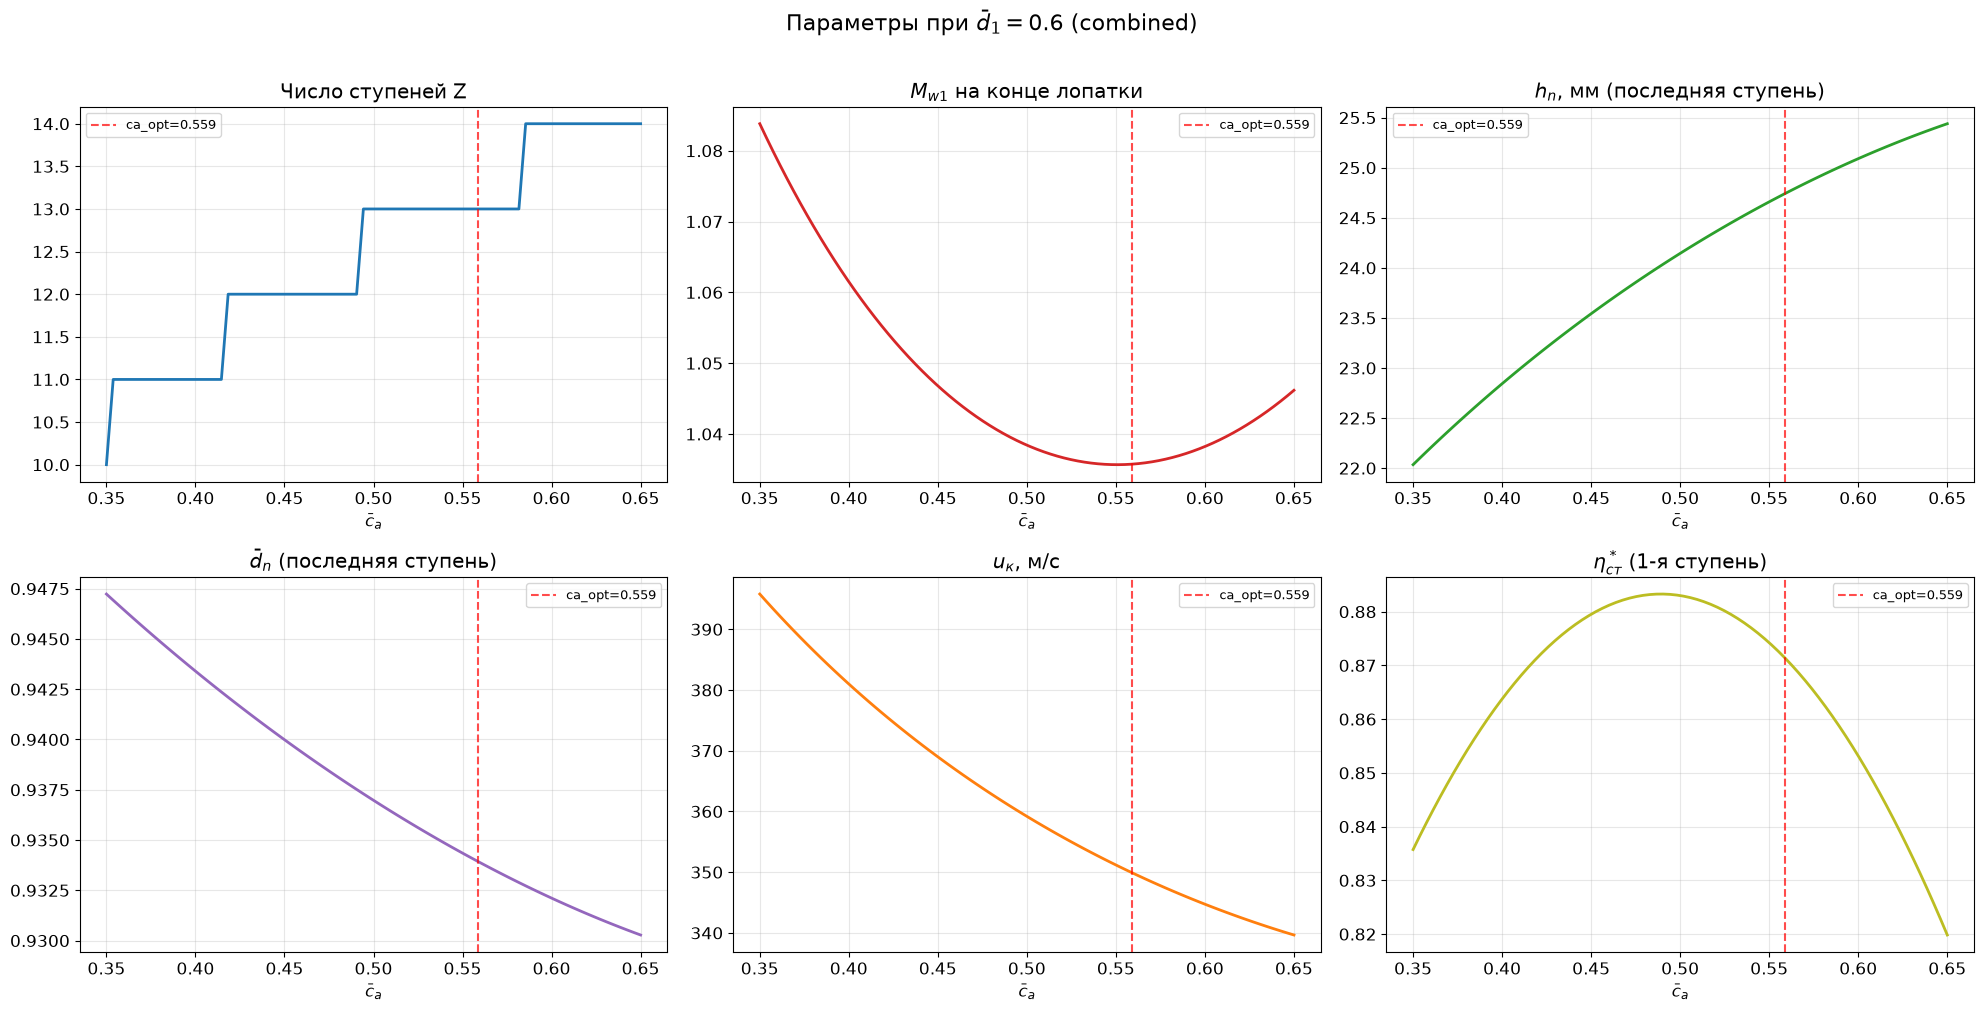

In [62]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

data_list = [
    (Z_grid[0], 'Число ступеней Z', 'tab:blue'),
    (Mw1_grid[0], '$M_{w1}$ на конце лопатки', 'tab:red'),
    (hn_grid[0], '$h_n$, мм (последняя ступень)', 'tab:green'),
    (dn_grid[0], '$\\bar{d}_n$ (последняя ступень)', 'tab:purple'),
    (uk_grid[0], '$u_к$, м/с', 'tab:orange'),
    (eta_grid[0], '$\\eta^*_{ст}$ (1-я ступень)', 'tab:olive'),
]

for ax, (dat, title, color) in zip(axes.flat, data_list):
    mask = ~np.isnan(dat)
    if mask.any():
        ax.plot(ca_range[mask], dat[mask], color=color, linewidth=2)
    ax.axvline(ca_opt, color='red', linestyle='--', alpha=0.7, label=f'ca_opt={ca_opt:.3f}')
    ax.set_xlabel('$\\bar{c}_a$')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Параметры при $\\bar{{d}}_1 = {d_range[0]}$ ({FLOW_PATH})', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 4. Предварительный расчёт проточной части

Формулы по п. 2.3 методики:
$$u_{к_1} = \sqrt[3]{\frac{\pi \cdot G \cdot n^2}{900 \cdot \bar{c}_{a_1} \cdot \rho_1 \cdot (1 - \bar{d}_1^2)}}$$
$$D_{к_1} = \frac{60 \cdot u_{к_1}}{\pi \cdot n}$$
$$h_1 = \frac{1}{2} D_{к_1}(1 - \bar{d}_1)$$


In [63]:
# Фиксируем оптимальные параметры
ca_bar_1 = ca_opt
d_bar_1 = d_opt
R_sr_base = 0.5

design = compute_preliminary_design(ca_bar_1, d_bar_1, R_sr_base)

u_k = design['u_k']
D_k = design['D_k']
D_vt_1 = d_bar_1 * D_k
tau_sr1 = design['tau_sr1']
D_sr_1 = tau_sr1 * D_k
h_1 = design['h_1']
h_n = design['h_n']
Z = design['Z']
if REMOVE_LAST_STAGE and Z > 4:
    Z -= 1
    print(f"REMOVE_LAST_STAGE = True → Z уменьшено: {Z+1} → {Z}")
d_bar_n = design['d_bar_n']
HT_bar_1 = design['HT_bar']

print("=" * 60)
print("РАЗМЕРЫ ПРОТОЧНОЙ ЧАСТИ")
print("=" * 60)
print(f"u_k     = {u_k:.2f} м/с")
print(f"D_k     = {D_k*1000:.1f} мм")
print(f"D_вт_1  = {D_vt_1*1000:.1f} мм")
print(f"D_ср_1  = {D_sr_1*1000:.1f} мм")
print(f"h_1     = {h_1*1000:.1f} мм")
print(f"h_n     = {h_n*1000:.1f} мм")
print(f"d_bar_1 = {d_bar_1:.4f}")
print(f"d_bar_n = {d_bar_n:.4f}")
print(f"Z       = {Z} ступеней")
print(f"ca_1    = {ca_bar_1*u_k:.1f} м/с")
print()
print(f"F_вх    = {F_vkh_area:.4f} м²  (площадь на выходе вх. патрубка)")
print(f"F_вых   = {F_vykh_area:.4f} м²  (площадь на входе вых. патрубка)")
print(f"F_1     = {np.pi/4*D_k**2*(1-d_bar_1**2):.4f} м²  (кольцевая площадь 1-й ступени)")


РАЗМЕРЫ ПРОТОЧНОЙ ЧАСТИ
u_k     = 349.94 м/с
D_k     = 777.1 мм
D_вт_1  = 466.3 мм
D_ср_1  = 640.8 мм
h_1     = 155.4 мм
h_n     = 24.7 мм
d_bar_1 = 0.6000
d_bar_n = 0.9339
Z       = 13 ступеней
ca_1    = 195.6 м/с

F_вх    = 0.3294 м²  (площадь на выходе вх. патрубка)
F_вых   = 0.0563 м²  (площадь на входе вых. патрубка)
F_1     = 0.3036 м²  (кольцевая площадь 1-й ступени)


## 5. Распределение параметров по ступеням

По п. 2.2 методики:
- $\bar{c}_a$ — плавное снижение от 1-й к последней ступени
- $\eta^*_a$ — максимум в средних ступенях, снижение к краям
- $\bar{H}_т$ — колоколообразное распределение
- $R_{ср}$ — 0.5, с повышением к последним ступеням
- $K_н$ — линейное убывание (влияние вязкости)


In [64]:
stages = np.arange(1, Z + 1)

# ---- c_a_bar: плавное убывание ----
ca_bar_last = max(0.36, ca_bar_1 - 0.018 * (Z - 1))
ca_bar_dist = ca_bar_1 - (ca_bar_1 - ca_bar_last) * ((stages - 1) / max(Z - 1, 1))**0.75

# ---- eta*: из полинома с коррекцией для первых/последних ступеней ----
eta_dist = np.array([eta_stage_poly(c) for c in ca_bar_dist])
eta_corr = np.ones(Z)
eta_corr[0] = 0.975
if Z > 1: eta_corr[1] = 0.988
if Z > 2: eta_corr[-1] = 0.975
if Z > 3: eta_corr[-2] = 0.988
eta_dist = eta_dist * eta_corr

# ---- H_T_bar: из полинома с коррекцией ----
HT_bar_dist = np.array([HT_bar_poly(c) for c in ca_bar_dist])
ht_corr = np.ones(Z)
ht_corr[0] = 0.88
if Z > 1: ht_corr[1] = 0.94
if Z > 2: ht_corr[-1] = 0.90
if Z > 3: ht_corr[-2] = 0.95
HT_bar_dist = HT_bar_dist * ht_corr

# ---- R_sr ----
R_dist = np.full(Z, 0.5)
if Z > 3:
    R_dist[-1] = 0.55
    R_dist[-2] = 0.52

# ---- K_H (поправочный коэффициент) ----
K_H_dist = np.linspace(0.99, max(0.94, 0.99 - 0.005 * (Z - 1)), Z)

# ---- Delta_Ca: изменение осевой скорости в ступени, м/с ----
delta_Ca_dist = np.linspace(6, 10, Z)

# ---- Масштабирование HT_bar для совпадения суммарного напора с H_tk ----
# Оценка суммарного теоретического напора от текущего распределения
H_tk_dist = np.sum(HT_bar_dist) * u_k**2
scale_HT = H_tk / H_tk_dist
HT_bar_dist = HT_bar_dist * scale_HT
print(f"Масштабирование HT_bar: scale = {scale_HT:.4f}  (H_tk_расп = {H_tk_dist/1000:.1f}, H_tk_цель = {H_tk/1000:.1f} кДж/кг)")

# Вывод таблицы
print(f"{'Ступень':>8} {'ca_bar':>8} {'HT_bar':>8} {'eta*':>8} {'R':>6} {'K_H':>6} {'dCa':>6}")
print("-" * 60)
for i in range(Z):
    print(f"{i+1:>8d} {ca_bar_dist[i]:>8.4f} {HT_bar_dist[i]:>8.4f} {eta_dist[i]:>8.4f} "
          f"{R_dist[i]:>6.3f} {K_H_dist[i]:>6.3f} {delta_Ca_dist[i]:>6.1f}")


Масштабирование HT_bar: scale = 0.8795  (H_tk_расп = 497.4, H_tk_цель = 437.4 кДж/кг)
 Ступень   ca_bar   HT_bar     eta*      R    K_H    dCa
------------------------------------------------------------
       1   0.5589   0.1974   0.8496  0.500  0.990    6.0
       2   0.5280   0.2285   0.8690  0.500  0.986    6.3
       3   0.5070   0.2550   0.8825  0.500  0.982    6.7
       4   0.4886   0.2648   0.8833  0.500  0.978    7.0
       5   0.4716   0.2732   0.8825  0.500  0.973    7.3
       6   0.4557   0.2807   0.8805  0.500  0.969    7.7
       7   0.4406   0.2873   0.8775  0.500  0.965    8.0
       8   0.4261   0.2933   0.8735  0.500  0.961    8.3
       9   0.4121   0.2988   0.8687  0.500  0.957    8.7
      10   0.3986   0.3037   0.8631  0.500  0.952    9.0
      11   0.3854   0.3082   0.8569  0.500  0.948    9.3
      12   0.3726   0.2967   0.8397  0.520  0.944    9.7
      13   0.3600   0.2844   0.8213  0.550  0.940   10.0


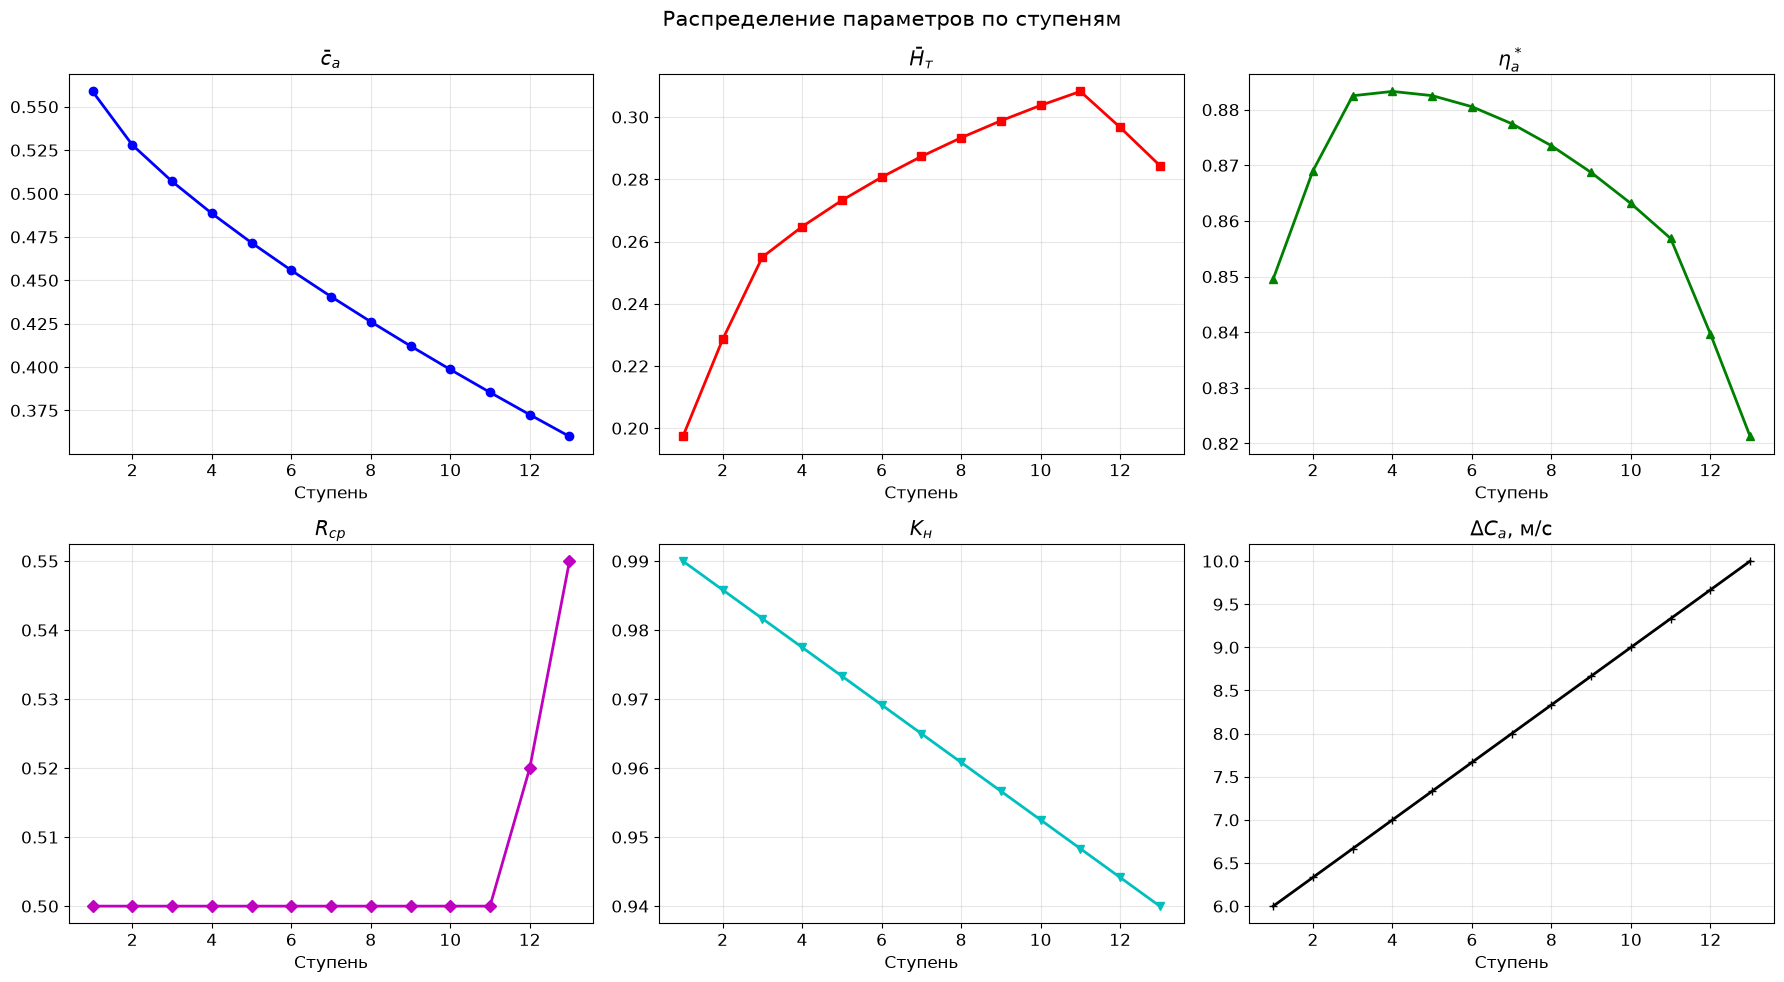

In [65]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].plot(stages, ca_bar_dist, 'bo-', lw=2)
axes[0,0].set_title('$\\bar{c}_a$')
axes[0,0].set_xlabel('Ступень')

axes[0,1].plot(stages, HT_bar_dist, 'rs-', lw=2)
axes[0,1].set_title('$\\bar{H}_т$')
axes[0,1].set_xlabel('Ступень')

axes[0,2].plot(stages, eta_dist, 'g^-', lw=2)
axes[0,2].set_title('$\\eta^*_a$')
axes[0,2].set_xlabel('Ступень')

axes[1,0].plot(stages, R_dist, 'mD-', lw=2)
axes[1,0].set_title('$R_{ср}$')
axes[1,0].set_xlabel('Ступень')

axes[1,1].plot(stages, K_H_dist, 'cv-', lw=2)
axes[1,1].set_title('$K_н$')
axes[1,1].set_xlabel('Ступень')

axes[1,2].plot(stages, delta_Ca_dist, 'k+-', lw=2)
axes[1,2].set_title('$\\Delta C_a$, м/с')
axes[1,2].set_xlabel('Ступень')

plt.suptitle('Распределение параметров по ступеням', fontsize=15)
plt.tight_layout()
plt.show()


## 6. Поступенчатый расчёт по средней линии тока (п. 3 методики)

31 шаг для каждой ступени — последовательный расчёт термодинамических и кинематических параметров.

После первого прохода выполняется итерационная коррекция $\bar{H}_т$ до совпадения $\pi^*_к$ с заданным (невязка < 1%).


In [66]:
# ================================================
# ПОСТУПЕНЧАТЫЙ РАСЧЁТ
# ================================================

# Массивы результатов (индекс 0..Z-1 = ступень 1..Z)
T1s = np.zeros(Z + 1)   # T* на входе
P1s = np.zeros(Z + 1)   # P* на входе
T1s[0] = T0_star
P1s[0] = P1_star

HT_dim   = np.zeros(Z)
Lz       = np.zeros(Z)
Had      = np.zeros(Z)
dT       = np.zeros(Z)
pi_st    = np.zeros(Z)
acr1     = np.zeros(Z)
acr3     = np.zeros(Z)
rcp1     = np.zeros(Z)
cu1_bar  = np.zeros(Z)
alpha1   = np.zeros(Z)
lam1     = np.zeros(Z)
F1       = np.zeros(Z)
d1_bar   = np.zeros(Z)
F3       = np.zeros(Z)
d3_bar   = np.zeros(Z)
rcp3     = np.zeros(Z)
rcp2     = np.zeros(Z)
cu2_bar  = np.zeros(Z)
beta1    = np.zeros(Z)
beta2    = np.zeros(Z)
alpha2   = np.zeros(Z)
alpha3   = np.zeros(Z)
eps_RK   = np.zeros(Z)
eps_NA   = np.zeros(Z)
w1       = np.zeros(Z)
c2       = np.zeros(Z)
Mw1_sr   = np.zeros(Z)
Mc2_sr   = np.zeros(Z)
ca1_dim  = np.zeros(Z)
ca2_dim  = np.zeros(Z)
ca2_bar  = np.zeros(Z)
h_blade  = np.zeros(Z)
Dk_arr   = np.zeros(Z + 1)  # Dk на входе каждой ступени
Dvt_arr  = np.zeros(Z + 1)  # Dvt на входе каждой ступени


# Режим переключения (для combined)
dvt_const_mode = False
i_switch = -1
D_vt_frozen = 0.0

# d_bar для первой ступени
d1_bar[0] = d_bar_1
Dk_arr[0] = D_k
Dvt_arr[0] = d_bar_1 * D_k

for i in range(Z):
    # ---- Шаг 1: Теоретический напор ----
    HT_dim[i] = HT_bar_dist[i] * u_k**2

    # ---- Шаг 2: Действительная работа ----
    Lz[i] = K_H_dist[i] * HT_dim[i]

    # ---- Шаг 3: Адиабатическая работа ----
    Had[i] = Lz[i] * eta_dist[i]

    # ---- Шаг 4: Повышение температуры ----
    dT[i] = Lz[i] / cp

    # ---- Шаг 5: T* на выходе ----
    T1s[i+1] = T1s[i] + dT[i]

    # ---- Шаг 6: Степень повышения давления ----
    pi_st[i] = (1.0 + Had[i] / (cp * T1s[i]))**(k / (k - 1.0))

    # ---- Шаг 7: P* на выходе ----
    P1s[i+1] = P1s[i] * pi_st[i]

    # ---- Шаг 8: Критические скорости ----
    acr1[i] = a_cr_func(T1s[i])
    acr3[i] = a_cr_func(T1s[i+1])

    # ---- Шаг 9: Средний радиус на входе ----
    rcp1[i] = np.sqrt((1.0 + d1_bar[i]**2) / 2.0)

    # ---- Шаг 10: c_u1_bar ----
    cu1_bar[i] = rcp1[i] * (1.0 - R_dist[i]) - HT_bar_dist[i] / (2.0 * rcp1[i])

    # Осевые скорости (u_k для безразмеривания — берём на конце лопатки текущей ступени)
    u_k_local = np.pi * Dk_arr[i] * n_rpm / 60.0
    ca1_dim[i] = ca_bar_dist[i] * u_k_local
    ca2_dim[i] = ca1_dim[i] - delta_Ca_dist[i]
    ca2_bar[i] = ca2_dim[i] / u_k_local

    # ---- Шаг 11: alpha_1 ----
    if abs(cu1_bar[i]) < 1e-10:
        alpha1[i] = np.pi / 2.0
    else:
        alpha1[i] = np.arctan2(ca_bar_dist[i], cu1_bar[i])

    # ---- Шаг 12: lambda_1 ----
    lam1[i] = ca1_dim[i] / (np.sin(alpha1[i]) * acr1[i])

    # ---- Шаг 14: Кольцевая площадь на входе ----
    q1_val = q_lam(lam1[i])
    if q1_val > 0:
        F1[i] = G * np.sqrt(Rg * T1s[i]) / (beta_k_val * P1s[i] * q1_val * np.sin(alpha1[i]))
    else:
        F1[i] = np.pi / 4 * Dk_arr[i]**2 * (1 - d1_bar[i]**2)

    # Пересчёт d_bar для i>0 в зависимости от режима
    if i > 0:
        if not dvt_const_mode:
            d1_sq = 1.0 - 4.0 * F1[i] / (np.pi * D_k**2)
            d1_bar[i] = np.sqrt(max(d1_sq, 0.01))
            Dk_arr[i] = D_k
            Dvt_arr[i] = d1_bar[i] * D_k
        else:
            Dk_sq = D_vt_frozen**2 + 4.0 * F1[i] / np.pi
            Dk_arr[i] = np.sqrt(Dk_sq)
            Dvt_arr[i] = D_vt_frozen
            d1_bar[i] = D_vt_frozen / Dk_arr[i]
            u_k_local = np.pi * Dk_arr[i] * n_rpm / 60.0
            ca1_dim[i] = ca_bar_dist[i] * u_k_local
            ca2_dim[i] = ca1_dim[i] - delta_Ca_dist[i]
            ca2_bar[i] = ca2_dim[i] / u_k_local

        rcp1[i] = np.sqrt((1.0 + d1_bar[i]**2) / 2.0)
        cu1_bar[i] = rcp1[i] * (1.0 - R_dist[i]) - HT_bar_dist[i] / (2.0 * rcp1[i])
        if abs(cu1_bar[i]) < 1e-10:
            alpha1[i] = np.pi / 2.0
        else:
            alpha1[i] = np.arctan2(ca_bar_dist[i], cu1_bar[i])
        lam1[i] = ca1_dim[i] / (np.sin(alpha1[i]) * acr1[i])

    # ---- Шаги 15-21: Выходное сечение (2 приближения) ----
    if i < Z - 1:
        a3_approx = alpha1[i]
    else:
        a3_approx = np.pi / 2.0

    lam3_a = ca2_dim[i] / (np.sin(a3_approx) * acr3[i])
    q3_a = q_lam(lam3_a)
    if q3_a > 0:
        F3_a = G * np.sqrt(Rg * T1s[i+1]) / (beta_k_val * P1s[i+1] * q3_a * np.sin(a3_approx))
    else:
        F3_a = F1[i] * 0.95

    if not dvt_const_mode:
        Dk_3 = D_k
        d3_sq = 1.0 - 4.0 * F3_a / (np.pi * Dk_3**2)
        d3_bar_a = np.sqrt(max(d3_sq, 0.01))
    else:
        Dk_3 = np.sqrt(D_vt_frozen**2 + 4.0 * F3_a / np.pi)
        d3_bar_a = D_vt_frozen / Dk_3

    rcp3_a = np.sqrt((1.0 + d3_bar_a**2) / 2.0)

    # Второе приближение: alpha_3 уточнённый
    if i < Z - 1:
        i_next = i + 1
        cu3_bar = rcp3_a * (1.0 - R_dist[i_next]) - HT_bar_dist[i_next] / (2.0 * rcp3_a)
        ca3_bar = ca_bar_dist[i_next] if i_next < Z else ca2_bar[i]
        if abs(cu3_bar) < 1e-10:
            alpha3[i] = np.pi / 2.0
        else:
            alpha3[i] = np.arctan2(ca3_bar, cu3_bar)
    else:
        alpha3[i] = np.pi / 2.0

    lam3 = ca2_dim[i] / (np.sin(alpha3[i]) * acr3[i])
    q3_val = q_lam(lam3)
    if q3_val > 0:
        F3[i] = G * np.sqrt(Rg * T1s[i+1]) / (beta_k_val * P1s[i+1] * q3_val * np.sin(alpha3[i]))
    else:
        F3[i] = F3_a

    if not dvt_const_mode:
        d3_sq = 1.0 - 4.0 * F3[i] / (np.pi * D_k**2)
        d3_bar[i] = np.sqrt(max(d3_sq, 0.01))
        Dk_3_final = D_k
    else:
        Dk_3_sq = D_vt_frozen**2 + 4.0 * F3[i] / np.pi
        Dk_3_final = np.sqrt(Dk_3_sq)
        d3_bar[i] = D_vt_frozen / Dk_3_final

    # Проверка переключения (combined)
    if FLOW_PATH == 'combined':
        h_3 = (Dk_3_final - d3_bar[i] * Dk_3_final) / 2.0
        if not dvt_const_mode and (h_3 * 1000 < H_MIN_MM or d3_bar[i] >= D_BAR_MAX):
            dvt_const_mode = True
            i_switch = i
            D_vt_frozen = Dvt_arr[i]
            Dk_3_sq = D_vt_frozen**2 + 4.0 * F3[i] / np.pi
            Dk_3_final = np.sqrt(Dk_3_sq)
            d3_bar[i] = D_vt_frozen / Dk_3_final

    if not dvt_const_mode:
        Dk_arr[i+1] = D_k
        Dvt_arr[i+1] = d3_bar[i] * D_k
    else:
        Dk_arr[i+1] = Dk_3_final
        Dvt_arr[i+1] = D_vt_frozen
    if i < Z - 1:
        d1_bar[i+1] = d3_bar[i]

    # ---- Шаг 22: r_cp3 ----
    rcp3[i] = np.sqrt((1.0 + d3_bar[i]**2) / 2.0)

    # ---- Шаг 23: r_cp2 (среднее) ----
    rcp2[i] = 0.5 * (rcp1[i] + rcp3[i])

    # ---- Шаг 24: c_u2_bar ----
    cu2_bar[i] = (HT_bar_dist[i] + cu1_bar[i] * rcp1[i]) / rcp2[i]

    # ---- Шаг 25: beta_1, beta_2 ----
    denom_b1 = rcp1[i] - cu1_bar[i]
    beta1[i] = np.arctan2(ca_bar_dist[i], denom_b1)
    denom_b2 = rcp2[i] - cu2_bar[i]
    beta2[i] = np.arctan2(ca2_bar[i], denom_b2)

    # ---- Шаг 26: alpha_2 ----
    alpha2[i] = np.arctan2(ca2_bar[i], cu2_bar[i])

    # ---- Шаг 27: Углы поворота ----
    eps_RK[i] = beta2[i] - beta1[i]
    eps_NA[i] = alpha3[i] - alpha2[i]

    # ---- Шаг 28: w_1 ----
    w1[i] = ca1_dim[i] / np.sin(beta1[i]) if np.sin(beta1[i]) > 0.01 else ca1_dim[i]

    # ---- Шаг 29: c_2 ----
    c2[i] = ca2_dim[i] / np.sin(alpha2[i]) if np.sin(alpha2[i]) > 0.01 else ca2_dim[i]

    # ---- Шаг 30: M_w1 на среднем радиусе ----
    T1_stat = T1s[i] * tau_lam(lam1[i])
    if T1_stat > 0:
        a1_loc = np.sqrt(k * Rg * T1_stat)
        Mw1_sr[i] = w1[i] / a1_loc

    # ---- Шаг 31: M_c2 ----
    lam_c2 = c2[i] / acr3[i]
    T2_stat = T1s[i+1] * tau_lam(lam_c2)
    if T2_stat > 0:
        a2_loc = np.sqrt(k * Rg * T2_stat)
        Mc2_sr[i] = c2[i] / a2_loc

    # Высота лопатки
    h_blade[i] = (Dk_arr[i] - Dvt_arr[i]) / 2.0

if i_switch >= 0:
    print(f"Переключение Dk=const → Dvt=const на ступени {i_switch + 1}")
    print(f"  D_вт замороженный = {D_vt_frozen*1000:.1f} мм")
else:
    print("Все ступени — Dk = const")
print("Поступенчатый расчёт завершён.")
print(f"  sum(Lz) = {np.sum(Lz)/1000:.1f} кДж/кг,  H_tk = {H_tk/1000:.1f} кДж/кг")


Переключение Dk=const → Dvt=const на ступени 12
  D_вт замороженный = 713.2 мм
Поступенчатый расчёт завершён.
  sum(Lz) = 421.5 кДж/кг,  H_tk = 437.4 кДж/кг


### 6.1 Итерационная коррекция $\bar{H}_т$

Корректируем распределение $\bar{H}_т$ до совпадения расчётного $\pi^*_к$ с заданным (невязка < 1%).


In [67]:
# ================================================
# ИТЕРАЦИОННАЯ КОРРЕКЦИЯ HT_bar_dist
# ================================================
HT_bar_dist_orig = HT_bar_dist.copy()

for n_iter in range(20):
    # Пересчёт поступенчатого расчёта с текущим HT_bar_dist
    T1s[0] = T0_star
    P1s[0] = P1_star
    dvt_const_mode_c = False
    D_vt_frozen_c = 0.0
    i_switch_c = -1
    d1_bar[0] = d_bar_1
    Dk_arr[0] = D_k
    Dvt_arr[0] = d_bar_1 * D_k

    for i in range(Z):
        HT_dim[i] = HT_bar_dist[i] * u_k**2
        Lz[i] = K_H_dist[i] * HT_dim[i]
        Had[i] = Lz[i] * eta_dist[i]
        dT[i] = Lz[i] / cp
        T1s[i+1] = T1s[i] + dT[i]
        pi_st[i] = (1.0 + Had[i] / (cp * T1s[i]))**(k / (k - 1.0))
        P1s[i+1] = P1s[i] * pi_st[i]
        acr1[i] = a_cr_func(T1s[i])
        acr3[i] = a_cr_func(T1s[i+1])
        rcp1[i] = np.sqrt((1.0 + d1_bar[i]**2) / 2.0)
        cu1_bar[i] = rcp1[i] * (1.0 - R_dist[i]) - HT_bar_dist[i] / (2.0 * rcp1[i])

        u_k_local = np.pi * Dk_arr[i] * n_rpm / 60.0
        ca1_dim[i] = ca_bar_dist[i] * u_k_local
        ca2_dim[i] = ca1_dim[i] - delta_Ca_dist[i]
        ca2_bar[i] = ca2_dim[i] / u_k_local

        if abs(cu1_bar[i]) < 1e-10:
            alpha1[i] = np.pi / 2.0
        else:
            alpha1[i] = np.arctan2(ca_bar_dist[i], cu1_bar[i])
        lam1[i] = ca1_dim[i] / (np.sin(alpha1[i]) * acr1[i])

        q1_val = q_lam(lam1[i])
        if q1_val > 0:
            F1[i] = G * np.sqrt(Rg * T1s[i]) / (beta_k_val * P1s[i] * q1_val * np.sin(alpha1[i]))
        else:
            F1[i] = np.pi / 4 * Dk_arr[i]**2 * (1 - d1_bar[i]**2)

        if i > 0:
            if not dvt_const_mode_c:
                d1_sq = 1.0 - 4.0 * F1[i] / (np.pi * D_k**2)
                d1_bar[i] = np.sqrt(max(d1_sq, 0.01))
                Dk_arr[i] = D_k
                Dvt_arr[i] = d1_bar[i] * D_k
            else:
                Dk_sq = D_vt_frozen_c**2 + 4.0 * F1[i] / np.pi
                Dk_arr[i] = np.sqrt(Dk_sq)
                Dvt_arr[i] = D_vt_frozen_c
                d1_bar[i] = D_vt_frozen_c / Dk_arr[i]
                u_k_local = np.pi * Dk_arr[i] * n_rpm / 60.0
                ca1_dim[i] = ca_bar_dist[i] * u_k_local
                ca2_dim[i] = ca1_dim[i] - delta_Ca_dist[i]
                ca2_bar[i] = ca2_dim[i] / u_k_local
            rcp1[i] = np.sqrt((1.0 + d1_bar[i]**2) / 2.0)
            cu1_bar[i] = rcp1[i] * (1.0 - R_dist[i]) - HT_bar_dist[i] / (2.0 * rcp1[i])
            if abs(cu1_bar[i]) < 1e-10:
                alpha1[i] = np.pi / 2.0
            else:
                alpha1[i] = np.arctan2(ca_bar_dist[i], cu1_bar[i])
            lam1[i] = ca1_dim[i] / (np.sin(alpha1[i]) * acr1[i])

        if i < Z - 1:
            a3_approx = alpha1[i]
        else:
            a3_approx = np.pi / 2.0
        lam3_a = ca2_dim[i] / (np.sin(a3_approx) * acr3[i])
        q3_a = q_lam(lam3_a)
        if q3_a > 0:
            F3_a = G * np.sqrt(Rg * T1s[i+1]) / (beta_k_val * P1s[i+1] * q3_a * np.sin(a3_approx))
        else:
            F3_a = F1[i] * 0.95

        if not dvt_const_mode_c:
            Dk_3 = D_k
            d3_sq = 1.0 - 4.0 * F3_a / (np.pi * Dk_3**2)
            d3_bar_a = np.sqrt(max(d3_sq, 0.01))
        else:
            Dk_3 = np.sqrt(D_vt_frozen_c**2 + 4.0 * F3_a / np.pi)
            d3_bar_a = D_vt_frozen_c / Dk_3
        rcp3_a = np.sqrt((1.0 + d3_bar_a**2) / 2.0)

        if i < Z - 1:
            i_next = i + 1
            cu3_bar = rcp3_a * (1.0 - R_dist[i_next]) - HT_bar_dist[i_next] / (2.0 * rcp3_a)
            ca3_bar = ca_bar_dist[i_next] if i_next < Z else ca2_bar[i]
            if abs(cu3_bar) < 1e-10:
                alpha3[i] = np.pi / 2.0
            else:
                alpha3[i] = np.arctan2(ca3_bar, cu3_bar)
        else:
            alpha3[i] = np.pi / 2.0

        lam3 = ca2_dim[i] / (np.sin(alpha3[i]) * acr3[i])
        q3_val = q_lam(lam3)
        if q3_val > 0:
            F3[i] = G * np.sqrt(Rg * T1s[i+1]) / (beta_k_val * P1s[i+1] * q3_val * np.sin(alpha3[i]))
        else:
            F3[i] = F3_a

        if not dvt_const_mode_c:
            d3_sq = 1.0 - 4.0 * F3[i] / (np.pi * D_k**2)
            d3_bar[i] = np.sqrt(max(d3_sq, 0.01))
            Dk_3_final = D_k
        else:
            Dk_3_final = np.sqrt(D_vt_frozen_c**2 + 4.0 * F3[i] / np.pi)
            d3_bar[i] = D_vt_frozen_c / Dk_3_final

        if FLOW_PATH == 'combined':
            h_3 = (Dk_3_final - d3_bar[i] * Dk_3_final) / 2.0
            if not dvt_const_mode_c and (h_3 * 1000 < H_MIN_MM or d3_bar[i] >= D_BAR_MAX):
                dvt_const_mode_c = True
                i_switch_c = i
                D_vt_frozen_c = Dvt_arr[i]
                Dk_3_final = np.sqrt(D_vt_frozen_c**2 + 4.0 * F3[i] / np.pi)
                d3_bar[i] = D_vt_frozen_c / Dk_3_final

        if not dvt_const_mode_c:
            Dk_arr[i+1] = D_k
            Dvt_arr[i+1] = d3_bar[i] * D_k
        else:
            Dk_arr[i+1] = Dk_3_final
            Dvt_arr[i+1] = D_vt_frozen_c
        if i < Z - 1:
            d1_bar[i+1] = d3_bar[i]

        rcp3[i] = np.sqrt((1.0 + d3_bar[i]**2) / 2.0)
        rcp2[i] = 0.5 * (rcp1[i] + rcp3[i])
        cu2_bar[i] = (HT_bar_dist[i] + cu1_bar[i] * rcp1[i]) / rcp2[i]
        beta1[i] = np.arctan2(ca_bar_dist[i], rcp1[i] - cu1_bar[i])
        beta2[i] = np.arctan2(ca2_bar[i], rcp2[i] - cu2_bar[i])
        alpha2[i] = np.arctan2(ca2_bar[i], cu2_bar[i])
        eps_RK[i] = beta2[i] - beta1[i]
        eps_NA[i] = alpha3[i] - alpha2[i]
        w1[i] = ca1_dim[i] / np.sin(beta1[i]) if np.sin(beta1[i]) > 0.01 else ca1_dim[i]
        c2[i] = ca2_dim[i] / np.sin(alpha2[i]) if np.sin(alpha2[i]) > 0.01 else ca2_dim[i]
        T1_stat = T1s[i] * tau_lam(lam1[i])
        if T1_stat > 0:
            Mw1_sr[i] = w1[i] / np.sqrt(k * Rg * T1_stat)
        lam_c2 = c2[i] / acr3[i]
        T2_stat = T1s[i+1] * tau_lam(lam_c2)
        if T2_stat > 0:
            Mc2_sr[i] = c2[i] / np.sqrt(k * Rg * T2_stat)
        h_blade[i] = (Dk_arr[i] - Dvt_arr[i]) / 2.0

    # Проверка невязки
    pi_la_calc = P1s[Z] / P1s[0]
    pi_k_calc = pi_la_calc * sigma_vkh * sigma_vykh
    delta_pi = (pi_k_calc - pi_k_star) / pi_k_star * 100

    if abs(delta_pi) < 1.0:
        print(f"Итерация {n_iter+1}: Δπ* = {delta_pi:+.3f}% — СОШЛОСЬ")
        break

    # Коррекция: масштабируем HT_bar_dist
    # Используем логарифмическую коррекцию (pi ~ exp(work))
    corr = np.log(pi_la) / np.log(pi_la_calc)
    HT_bar_dist = HT_bar_dist * corr
    print(f"Итерация {n_iter+1}: Δπ* = {delta_pi:+.2f}%, корр = {corr:.4f}")


i_switch = i_switch_c
D_vt_frozen = D_vt_frozen_c
dvt_const_mode = dvt_const_mode_c

print(f"Итого итераций: {n_iter+1}")
print(f"Финальная невязка: Δπ* = {delta_pi:+.3f}%")
print(f"Масштаб HT_bar: {HT_bar_dist[Z//2] / HT_bar_dist_orig[Z//2]:.4f} (средняя ступень)")


Итерация 1: Δπ* = -15.51%, корр = 1.0615
Итерация 2: Δπ* = -5.69%, корр = 1.0206
Итерация 3: Δπ* = -2.03%, корр = 1.0071
Итерация 4: Δπ* = -0.717% — СОШЛОСЬ
Итого итераций: 4
Финальная невязка: Δπ* = -0.717%
Масштаб HT_bar: 1.0910 (средняя ступень)


In [68]:
# Таблица результатов (по образцу табл. 2 методики)
print("=" * 120)
print(f"РЕЗУЛЬТАТЫ ПОСТУПЕНЧАТОГО РАСЧЁТА ({FLOW_PATH})")
print("=" * 120)

hdr = f"{'Параметр':<20} {'Разм.':<8}"
for i in range(Z):
    hdr += f"{'Ст.'+str(i+1):>9}"
print(hdr)
print("-" * 120)

def row(name, unit, arr, fmt=".1f"):
    s = f"{name:<20} {unit:<8}"
    for v in arr:
        s += f"{v:>9{fmt}}"
    print(s)

row("D_k", "мм", Dk_arr[:Z]*1000, ".1f")
row("D_вт", "мм", Dvt_arr[:Z]*1000, ".1f")
u_k_stages = np.pi * Dk_arr[:Z] * n_rpm / 60.0
row("u_k", "м/с", u_k_stages, ".1f")
row("d_bar_1", "-", d1_bar, ".4f")
row("d_bar_3", "-", d3_bar, ".4f")
row("h_лоп", "мм", h_blade*1000, ".1f")
row("ca_bar_1", "-", ca_bar_dist, ".4f")
row("ca_1", "м/с", ca1_dim, ".1f")
row("ca_2", "м/с", ca2_dim, ".1f")
row("HT_bar", "-", HT_bar_dist, ".4f")
row("H_T", "Дж/кг", HT_dim, ".0f")
row("eta*_a", "-", eta_dist, ".4f")
row("K_H", "-", K_H_dist, ".3f")
row("R_sr", "-", R_dist, ".3f")
row("L_z", "Дж/кг", Lz, ".0f")
row("H_ад", "Дж/кг", Had, ".0f")
row("dT*", "К", dT, ".2f")
row("T*_1", "К", T1s[:Z], ".1f")
row("T*_3", "К", T1s[1:Z+1], ".1f")
row("pi*_ст", "-", pi_st, ".4f")
row("P*_1, кПа", "кПа", P1s[:Z]/1000, ".2f")
row("P*_3, кПа", "кПа", P1s[1:Z+1]/1000, ".2f")
row("alpha_1", "°", np.degrees(alpha1), ".1f")
row("alpha_2", "°", np.degrees(alpha2), ".1f")
row("alpha_3", "°", np.degrees(alpha3), ".1f")
row("beta_1", "°", np.degrees(beta1), ".1f")
row("beta_2", "°", np.degrees(beta2), ".1f")
row("eps_РК", "°", np.degrees(eps_RK), ".1f")
row("eps_НА", "°", np.degrees(eps_NA), ".1f")
row("w_1", "м/с", w1, ".1f")
row("c_2", "м/с", c2, ".1f")
row("M_w1_ср", "-", Mw1_sr, ".3f")
row("M_c2_ср", "-", Mc2_sr, ".3f")


РЕЗУЛЬТАТЫ ПОСТУПЕНЧАТОГО РАСЧЁТА (combined)
Параметр             Разм.        Ст.1     Ст.2     Ст.3     Ст.4     Ст.5     Ст.6     Ст.7     Ст.8     Ст.9    Ст.10    Ст.11    Ст.12    Ст.13
------------------------------------------------------------------------------------------------------------------------
D_k                  мм          777.1    777.1    777.1    777.1    777.1    777.1    777.1    777.1    777.1    777.1    777.1    772.0    768.0
D_вт                 мм          466.3    519.1    568.1    607.0    635.8    657.7    674.6    687.9    698.5    707.1    714.1    714.1    714.1
u_k                  м/с         349.9    349.9    349.9    349.9    349.9    349.9    349.9    349.9    349.9    349.9    349.9    347.6    345.8
d_bar_1              -          0.6000   0.6679   0.7310   0.7811   0.8182   0.8463   0.8681   0.8852   0.8989   0.9099   0.9189   0.9250   0.9298
d_bar_3              -          0.6743   0.7323   0.7808   0.8172   0.8448   0.8663   0.8832   0.89

## 7. Проверка суммарных параметров

In [69]:
# ================================================
# ВЕРИФИКАЦИЯ
# ================================================

# Степень повышения давления лопаточного аппарата
pi_la_calc = P1s[Z] / P1s[0]

# КПД лопаточного аппарата
eta_la_calc = T0_star * (pi_la_calc**((k-1)/k) - 1) / (T1s[Z] - T1s[0])

# Степень повышения давления компрессора
pi_k_calc = pi_la_calc * sigma_vkh * sigma_vykh

# КПД компрессора
eta_k_calc = T0_star * (pi_k_calc**((k-1)/k) - 1) / (T1s[Z] - T0_star)

# Мощность привода
N_k = G * np.sum(Lz) / 1000  # кВт

print("=" * 60)
print("СУММАРНЫЕ ПАРАМЕТРЫ КОМПРЕССОРА")
print("=" * 60)
print(f"pi*_ла (расчёт)  = {pi_la_calc:.3f}")
print(f"pi*_ла (оценка)  = {pi_la:.3f}")
print(f"eta*_ла (расчёт) = {eta_la_calc:.4f}")
print(f"eta*_ла (оценка) = {eta_la:.4f}")
print()
print(f"pi*_к (расчёт)   = {pi_k_calc:.3f}")
print(f"pi*_к (задание)  = {pi_k_star:.1f}")
print(f"eta*_к (расчёт)  = {eta_k_calc:.4f}")
print(f"eta*_к (оценка)  = {eta_k_star_est:.4f}")
print()
print(f"T*_вых           = {T1s[Z]:.1f} К")
print(f"P*_вых           = {P1s[Z]/1000:.1f} кПа")
print(f"N_к              = {N_k:.0f} кВт = {N_k/1000:.1f} МВт")
print()

# Невязка по pi*
delta_pi = (pi_k_calc - pi_k_star) / pi_k_star * 100
print(f"Невязка по pi*_к: {delta_pi:+.2f}%")
if abs(delta_pi) > 5:
    print("  >> ВНИМАНИЕ: невязка > 5%. Требуется коррекция распределения H_T_bar.")
else:
    print("  >> Невязка приемлема.")


СУММАРНЫЕ ПАРАМЕТРЫ КОМПРЕССОРА
pi*_ла (расчёт)  = 18.237
pi*_ла (оценка)  = 18.368
eta*_ла (расчёт) = 0.8131
eta*_ла (оценка) = 0.8578

pi*_к (расчёт)   = 18.070
pi*_к (задание)  = 18.2
eta*_к (расчёт)  = 0.8093
eta*_к (оценка)  = 0.8538

T*_вых           = 745.8 К
P*_вых           = 1836.7 кПа
N_к              = 26991 кВт = 27.0 МВт

Невязка по pi*_к: -0.72%
  >> Невязка приемлема.


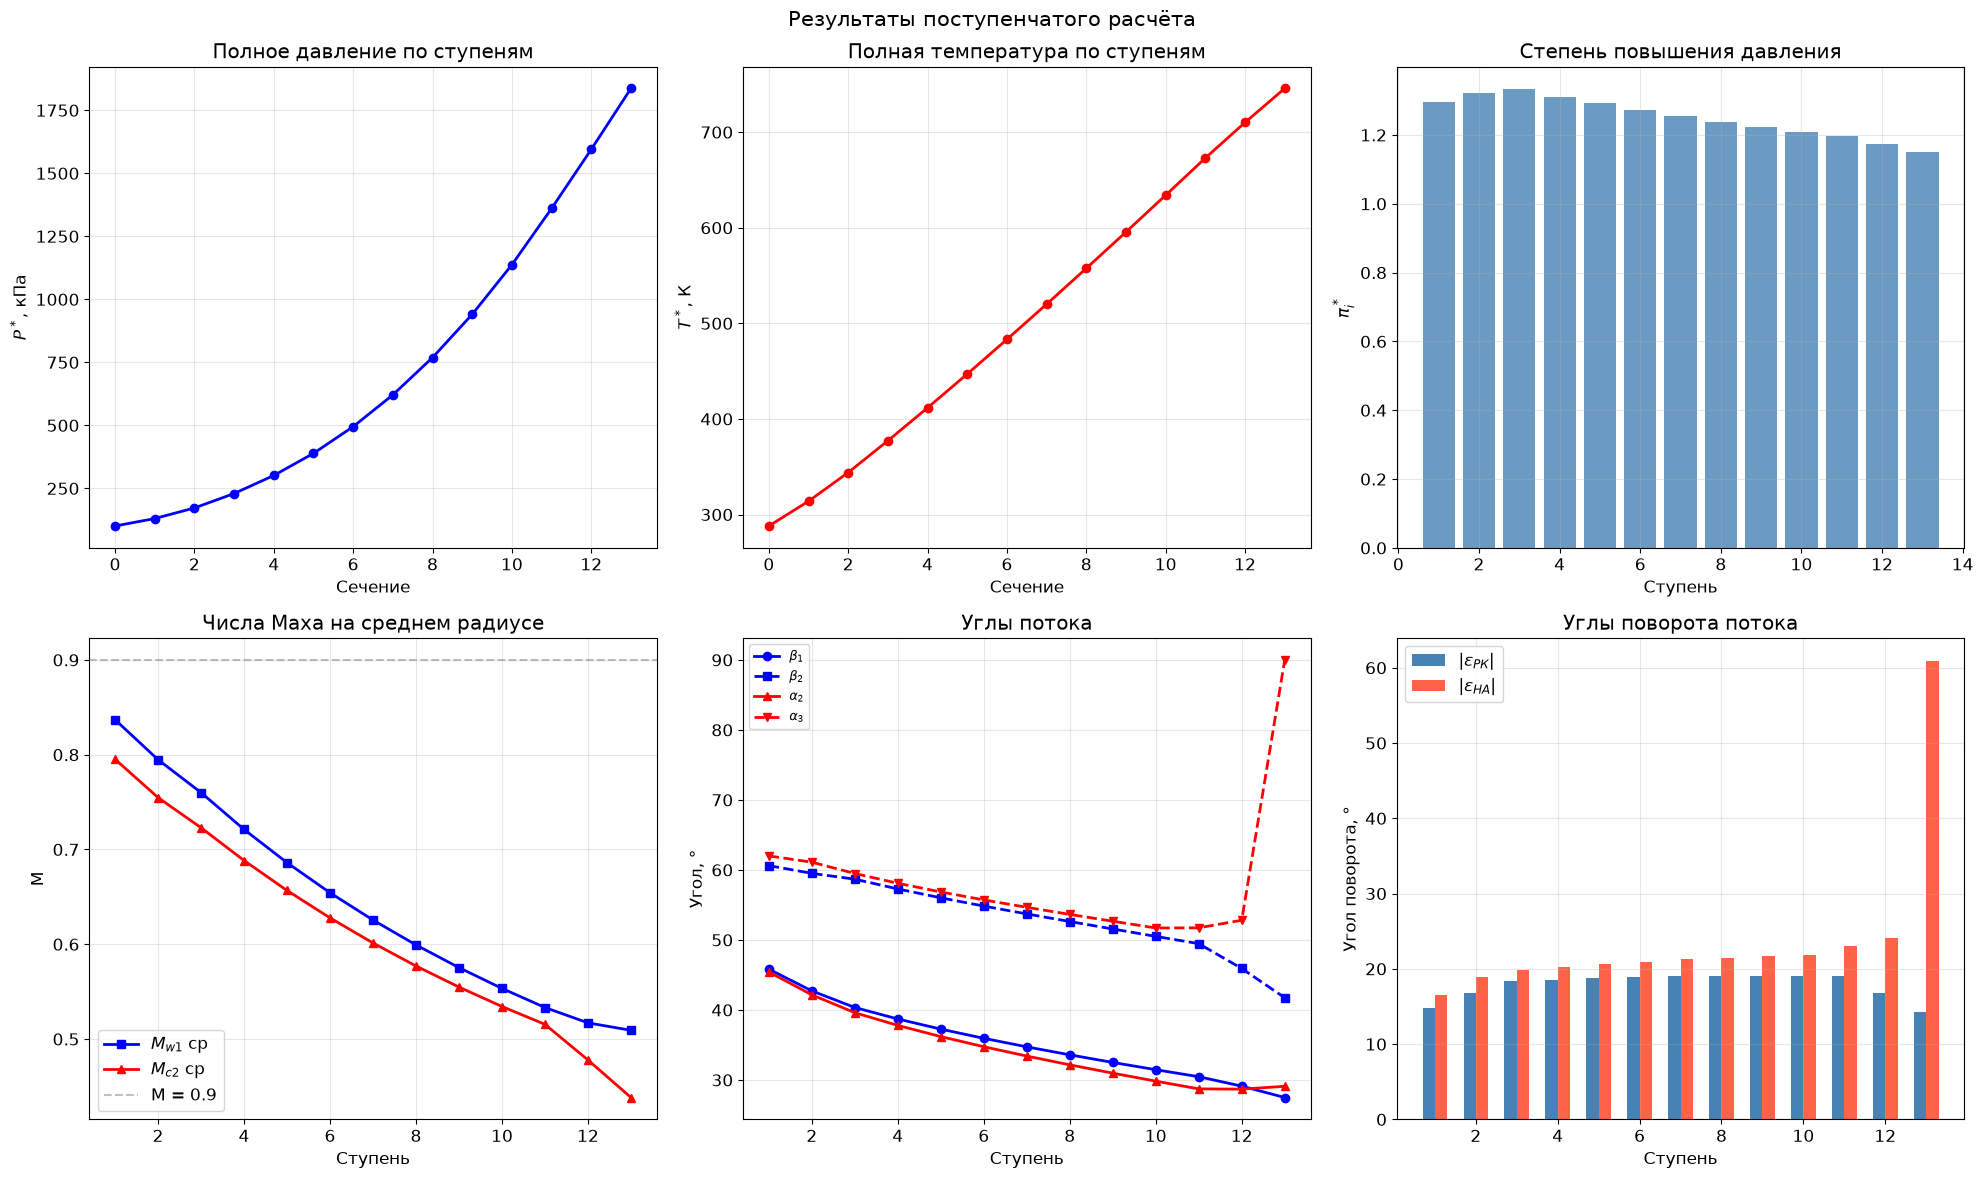

In [70]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# P* по ступеням
axes[0,0].plot(range(Z+1), P1s/1000, 'bo-', lw=2, markersize=6)
axes[0,0].set_xlabel('Сечение')
axes[0,0].set_ylabel('$P^*$, кПа')
axes[0,0].set_title('Полное давление по ступеням')

# T* по ступеням
axes[0,1].plot(range(Z+1), T1s, 'ro-', lw=2, markersize=6)
axes[0,1].set_xlabel('Сечение')
axes[0,1].set_ylabel('$T^*$, К')
axes[0,1].set_title('Полная температура по ступеням')

# pi* по ступеням
axes[0,2].bar(stages, pi_st, color='steelblue', alpha=0.8)
axes[0,2].set_xlabel('Ступень')
axes[0,2].set_ylabel('$\\pi^*_i$')
axes[0,2].set_title('Степень повышения давления')

# M_w1 и M_c2
axes[1,0].plot(stages, Mw1_sr, 'bs-', lw=2, label='$M_{w1}$ ср')
axes[1,0].plot(stages, Mc2_sr, 'r^-', lw=2, label='$M_{c2}$ ср')
axes[1,0].axhline(0.9, color='gray', ls='--', alpha=0.5, label='M = 0.9')
axes[1,0].set_xlabel('Ступень')
axes[1,0].set_ylabel('M')
axes[1,0].set_title('Числа Маха на среднем радиусе')
axes[1,0].legend()

# Углы
axes[1,1].plot(stages, np.degrees(beta1), 'b-o', lw=2, label='$\\beta_1$')
axes[1,1].plot(stages, np.degrees(beta2), 'b--s', lw=2, label='$\\beta_2$')
axes[1,1].plot(stages, np.degrees(alpha2), 'r-^', lw=2, label='$\\alpha_2$')
axes[1,1].plot(stages, np.degrees(alpha3), 'r--v', lw=2, label='$\\alpha_3$')
axes[1,1].set_xlabel('Ступень')
axes[1,1].set_ylabel('Угол, °')
axes[1,1].set_title('Углы потока')
axes[1,1].legend(fontsize=9)

# Углы поворота
axes[1,2].bar(stages - 0.15, np.degrees(np.abs(eps_RK)), 0.3, label='$|\\varepsilon_{РК}|$', color='steelblue')
axes[1,2].bar(stages + 0.15, np.degrees(np.abs(eps_NA)), 0.3, label='$|\\varepsilon_{НА}|$', color='tomato')
axes[1,2].set_xlabel('Ступень')
axes[1,2].set_ylabel('Угол поворота, °')
axes[1,2].set_title('Углы поворота потока')
axes[1,2].legend()

plt.suptitle('Результаты поступенчатого расчёта', fontsize=15)
plt.tight_layout()
plt.show()


## 8. Меридиональное сечение проточной части

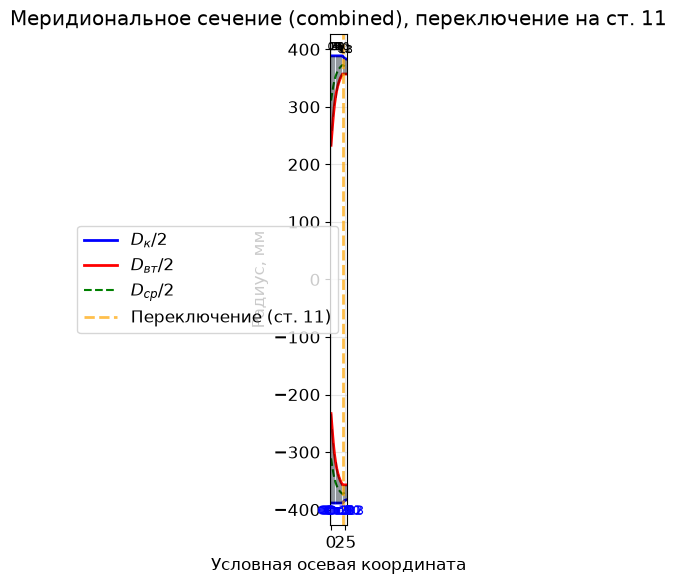

Высота лопатки 1-й ступени:      155.4 мм
Высота лопатки последней ступени: 26.3 мм
Переключение: ступень 11, Dvt замор. = 714.1 мм


In [71]:
# Построение меридионального сечения
fig, ax = plt.subplots(1, 1, figsize=(16, 6))

z = np.arange(Z + 1) * 2.0

r_outer = Dk_arr[:Z+1] / 2 * 1000  # мм
r_inner = Dvt_arr[:Z+1] / 2 * 1000  # мм

ax.fill_between(z, r_inner, r_outer, alpha=0.15, color='steelblue')
ax.fill_between(z, -r_inner, -r_outer, alpha=0.15, color='steelblue')

ax.plot(z, r_outer, 'b-', lw=2, label='$D_к/2$')
ax.plot(z, -r_outer, 'b-', lw=2)
ax.plot(z, r_inner, 'r-', lw=2, label='$D_{вт}/2$')
ax.plot(z, -r_inner, 'r-', lw=2)

r_mid = 0.5 * (r_inner + r_outer)
ax.plot(z, r_mid, 'g--', lw=1.5, label='$D_{ср}/2$')
ax.plot(z, -r_mid, 'g--', lw=1.5)

for i in range(Z + 1):
    ax.plot([z[i], z[i]], [r_inner[i], r_outer[i]], 'k-', lw=0.5, alpha=0.5)
    ax.plot([z[i], z[i]], [-r_inner[i], -r_outer[i]], 'k-', lw=0.5, alpha=0.5)
    ax.text(z[i], r_outer[i] + 10, f'{i}', ha='center', fontsize=8)

for i in range(Z):
    ax.text(z[i] + 1.0, -r_outer[0] - 20, f'Ст.{i+1}', ha='center', fontsize=9,
            color='blue')

if i_switch >= 0:
    z_sw = z[i_switch]
    ax.axvline(z_sw, color='orange', ls='--', lw=2, alpha=0.7, label=f'Переключение (ст. {i_switch+1})')

ax.set_xlabel('Условная осевая координата')
ax.set_ylabel('Радиус, мм')
title_str = f'Меридиональное сечение ({FLOW_PATH})'
if i_switch >= 0:
    title_str += f', переключение на ст. {i_switch+1}'
ax.set_title(title_str)
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Высота лопатки 1-й ступени:      {h_blade[0]*1000:.1f} мм")
h_n_final = (Dk_arr[Z] - Dvt_arr[Z]) / 2.0
print(f"Высота лопатки последней ступени: {h_n_final*1000:.1f} мм")
if i_switch >= 0:
    print(f"Переключение: ступень {i_switch+1}, Dvt замор. = {D_vt_frozen*1000:.1f} мм")



## 9. Профилирование решёток (п. 4 методики)

Полиномы из оцифрованных графиков:

Рис. 9: $\varepsilon_{b/t=1} = -2.1909 \cdot 10^{-5} \beta_2^3 + 3.7957 \cdot 10^{-3} \beta_2^2 + 0.262104 \beta_2 - 4.49505$

Рис. 10: $\frac{\varepsilon}{\varepsilon_{b/t=1}} = 0.085078 (b/t)^3 - 0.562903 (b/t)^2 + 1.516152 (b/t) - 0.025814$

Угол атаки: $i_0 = i_{0_0} - n_0 \cdot \Theta$

$i_{0_0} = -0.001 \beta_1^2 + 0.580 \beta_1 - 10.791$

$n_0 = -0.210 (b/t)^2 + 1.073 (b/t) + 0.136$


In [72]:
# ================================================
# ПРОФИЛИРОВАНИЕ РЕШЁТОК
# ================================================

def eps_bt1(beta2_deg):
    # Угол поворота при b/t = 1 (рис. 9)
    b = beta2_deg
    return -2.1909e-5 * b**3 + 3.7957e-3 * b**2 + 0.262104 * b - 4.49505

def eps_ratio(bt):
    # eps/eps_{b/t=1} от b/t (рис. 10)
    return 0.085078 * bt**3 - 0.562903 * bt**2 + 1.516152 * bt - 0.025814

def find_bt(eps_required, beta2_deg):
    # Находит b/t для заданного угла поворота eps
    e1 = eps_bt1(beta2_deg)
    if e1 <= 0:
        return 1.0
    ratio = eps_required / e1
    # Решение: eps_ratio(bt) = ratio
    try:
        bt = brentq(lambda x: eps_ratio(x) - ratio, 0.4, 2.5)
    except ValueError:
        bt = 1.0
    return bt

def i00_poly(beta1_deg):
    # i_{0_0} от beta_1 (рис. 12)
    return -0.001 * beta1_deg**2 + 0.580 * beta1_deg - 10.791

def n0_poly(bt):
    # n_0 от b/t (рис. 12)
    return -0.210 * bt**2 + 1.073 * bt + 0.136

# Профилирование для каждой ступени
print(f"{'Ступ':>5} {'beta1':>7} {'beta2':>7} {'eps_РК':>7} {'b/t_РК':>7} "
      f"{'alpha2':>7} {'alpha3':>7} {'eps_НА':>7} {'b/t_НА':>7} "
      f"{'Theta_РК':>9} {'Theta_НА':>9} {'theta_РК':>9} {'theta_НА':>9}")
print("-" * 130)

bt_RK = np.zeros(Z)
bt_NA = np.zeros(Z)
Theta_RK = np.zeros(Z)
Theta_NA = np.zeros(Z)
theta_RK = np.zeros(Z)
theta_NA = np.zeros(Z)
X_f = 0.45  # параболическая средняя линия

for i in range(Z):
    b1_deg = np.degrees(beta1[i])
    b2_deg = np.degrees(beta2[i])
    a2_deg = np.degrees(alpha2[i])
    a3_deg = np.degrees(alpha3[i])

    eps_rk_deg = abs(np.degrees(eps_RK[i]))
    eps_na_deg = abs(np.degrees(eps_NA[i]))

    # b/t для РК
    bt_RK[i] = find_bt(eps_rk_deg, b2_deg) if eps_rk_deg > 0 else 1.0
    # b/t для НА
    bt_NA[i] = find_bt(eps_na_deg, a3_deg) if eps_na_deg > 0 else 1.0

    # Углы атаки (номинальный режим)
    i_RK = 2.5 * (bt_RK[i] - 1.0)
    i_NA = 2.5 * (bt_NA[i] - 2.0)

    # Коэффициент m для угла отставания
    m_RK = 0.23 * (2*X_f)**2 + 0.18 - 0.002 * b2_deg
    m_NA = 0.23 * (2*X_f)**2 + 0.18 - 0.002 * a3_deg

    # Угол изгиба Theta: Theta = (eps - i + delta), delta = m*Theta*sqrt(t/b)
    # => Theta * (1 - m*sqrt(t/b)) = eps - i
    # => Theta = (eps - i) / (1 - m/sqrt(b/t))
    denom_rk = 1.0 - m_RK / np.sqrt(bt_RK[i]) if bt_RK[i] > 0 else 1.0
    Theta_RK[i] = (eps_rk_deg - i_RK) / denom_rk if abs(denom_rk) > 0.01 else eps_rk_deg

    denom_na = 1.0 - m_NA / np.sqrt(bt_NA[i]) if bt_NA[i] > 0 else 1.0
    Theta_NA[i] = (eps_na_deg - i_NA) / denom_na if abs(denom_na) > 0.01 else eps_na_deg

    # Угол установки
    chi1 = 0.6  # для X_f = 0.45
    theta_RK[i] = chi1 * Theta_RK[i] + b1_deg + i_RK
    theta_NA[i] = chi1 * Theta_NA[i] + a2_deg + i_NA

    print(f"{i+1:>5d} {b1_deg:>7.1f} {b2_deg:>7.1f} {eps_rk_deg:>7.1f} {bt_RK[i]:>7.3f} "
          f"{a2_deg:>7.1f} {a3_deg:>7.1f} {eps_na_deg:>7.1f} {bt_NA[i]:>7.3f} "
          f"{Theta_RK[i]:>9.1f} {Theta_NA[i]:>9.1f} {theta_RK[i]:>9.1f} {theta_NA[i]:>9.1f}")


 Ступ   beta1   beta2  eps_РК  b/t_РК  alpha2  alpha3  eps_НА  b/t_НА  Theta_РК  Theta_НА  theta_РК  theta_НА
----------------------------------------------------------------------------------------------------------------------------------
    1    45.8    60.6    14.8   0.625    45.4    62.0    16.6   0.695      22.8      28.0      58.6      58.9
    2    42.7    59.5    16.8   0.765    42.2    61.1    18.9   0.859      24.2      29.6      56.7      57.1
    3    40.4    58.7    18.3   0.891    39.6    59.5    19.9   0.978      25.3      29.9      55.2      55.0
    4    38.7    57.3    18.6   0.958    37.8    58.1    20.3   1.068      25.1      29.9      53.7      53.4
    5    37.3    56.0    18.8   1.024    36.2    56.9    20.7   1.159      25.0      29.7      52.3      51.9
    6    35.9    54.8    18.9   1.090    34.8    55.7    21.0   1.255      24.7      29.6      51.0      50.6
    7    34.7    53.7    19.0   1.159    33.4    54.7    21.2   1.357      24.5      29.3      49.8

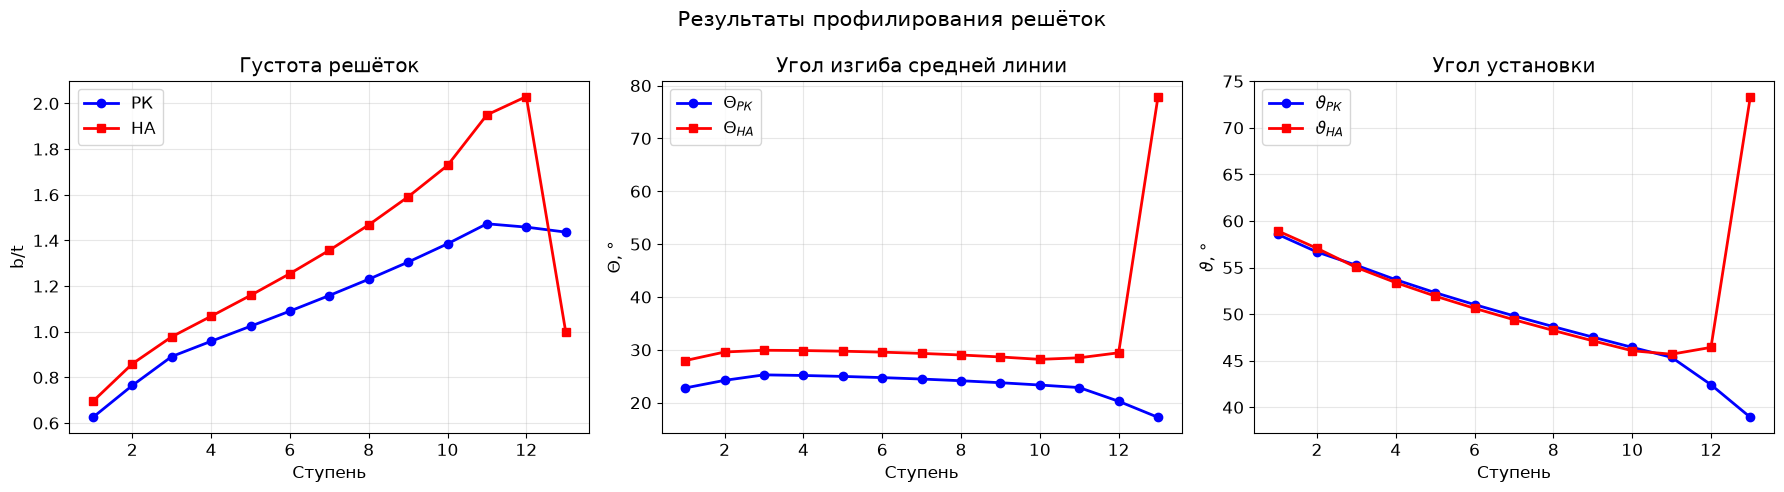

In [73]:
# Построение густоты и углов по ступеням
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(stages, bt_RK, 'bo-', lw=2, label='РК')
axes[0].plot(stages, bt_NA, 'rs-', lw=2, label='НА')
axes[0].set_xlabel('Ступень')
axes[0].set_ylabel('b/t')
axes[0].set_title('Густота решёток')
axes[0].legend()

axes[1].plot(stages, Theta_RK, 'bo-', lw=2, label='$\\Theta_{РК}$')
axes[1].plot(stages, Theta_NA, 'rs-', lw=2, label='$\\Theta_{НА}$')
axes[1].set_xlabel('Ступень')
axes[1].set_ylabel('$\\Theta$, °')
axes[1].set_title('Угол изгиба средней линии')
axes[1].legend()

axes[2].plot(stages, theta_RK, 'bo-', lw=2, label='$\\vartheta_{РК}$')
axes[2].plot(stages, theta_NA, 'rs-', lw=2, label='$\\vartheta_{НА}$')
axes[2].set_xlabel('Ступень')
axes[2].set_ylabel('$\\vartheta$, °')
axes[2].set_title('Угол установки')
axes[2].legend()

plt.suptitle('Результаты профилирования решёток', fontsize=15)
plt.tight_layout()
plt.show()


## 10. Треугольники скоростей (средняя ступень)

In [74]:
# Треугольник скоростей для средней ступени
i_mid = Z // 2

ca_1_m = ca1_dim[i_mid]
ca_2_m = ca2_dim[i_mid]
cu_1_m = cu1_bar[i_mid] * u_k
cu_2_m = cu2_bar[i_mid] * u_k
u_sr_m = rcp1[i_mid] * u_k
u_sr2_m = rcp2[i_mid] * u_k

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Перед РК
ax = axes[0]
ax.set_title(f'Перед РК (ступень {i_mid+1})')
# Абсолютная скорость c1
ax.annotate('', xy=(cu_1_m, ca_1_m), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2))
ax.text(cu_1_m/2, ca_1_m/2 + 10, '$c_1$', color='blue', fontsize=14)
# Окружная скорость u
ax.annotate('', xy=(u_sr_m, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.text(u_sr_m/2, -15, '$u$', color='green', fontsize=14)
# Относительная скорость w1
wu_1 = cu_1_m - u_sr_m
ax.annotate('', xy=(wu_1 + u_sr_m, ca_1_m), xytext=(u_sr_m, 0),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text((cu_1_m + u_sr_m)/2 - 30, ca_1_m/2, '$w_1$', color='red', fontsize=14)

ax.set_xlabel('$c_u$, м/с')
ax.set_ylabel('$c_a$, м/с')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# После РК
ax = axes[1]
ax.set_title(f'После РК (ступень {i_mid+1})')
ax.annotate('', xy=(cu_2_m, ca_2_m), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2))
ax.text(cu_2_m/2 + 5, ca_2_m/2 + 10, '$c_2$', color='blue', fontsize=14)
ax.annotate('', xy=(u_sr2_m, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.text(u_sr2_m/2, -15, '$u$', color='green', fontsize=14)
wu_2 = cu_2_m - u_sr2_m
ax.annotate('', xy=(wu_2 + u_sr2_m, ca_2_m), xytext=(u_sr2_m, 0),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text((cu_2_m + u_sr2_m)/2 + 5, ca_2_m/2, '$w_2$', color='red', fontsize=14)

ax.set_xlabel('$c_u$, м/с')
ax.set_ylabel('$c_a$, м/с')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.suptitle(f'Треугольники скоростей (ступень {i_mid+1}, средний радиус)', fontsize=15)
plt.tight_layout()
plt.show()

print(f"Ступень {i_mid+1}:")
print(f"  c_a1 = {ca_1_m:.1f} м/с,  c_u1 = {cu_1_m:.1f} м/с")
print(f"  c_a2 = {ca_2_m:.1f} м/с,  c_u2 = {cu_2_m:.1f} м/с")
print(f"  u_ср = {u_sr_m:.1f} м/с")
print(f"  w_1  = {w1[i_mid]:.1f} м/с,  c_2  = {c2[i_mid]:.1f} м/с")
print(f"  beta_1 = {np.degrees(beta1[i_mid]):.1f}°,  beta_2 = {np.degrees(beta2[i_mid]):.1f}°")
print(f"  alpha_1 = {np.degrees(alpha1[i_mid]):.1f}°,  alpha_2 = {np.degrees(alpha2[i_mid]):.1f}°")


MemoryError: std::bad_alloc

<Figure size 1600x700 with 2 Axes>

Ступень 7:
  c_a1 = 154.2 м/с,  c_u1 = 105.3 м/с
  c_a2 = 146.2 м/с,  c_u2 = 221.6 м/с
  u_ср = 327.7 м/с
  w_1  = 270.6 м/с,  c_2  = 265.5 м/с
  beta_1 = 34.7°,  beta_2 = 53.7°
  alpha_1 = 55.7°,  alpha_2 = 33.4°


## 11. Профиль А-40 (табл. 4 методики)

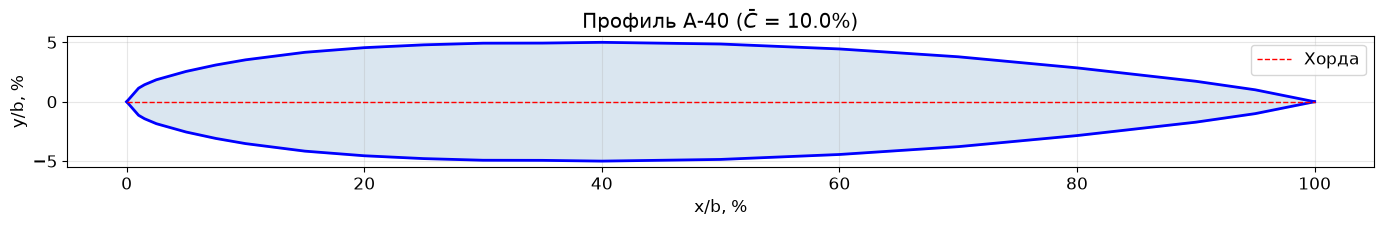

In [75]:
# Координаты профиля А-40 (симметричный)
xb_pct = np.array([0, 1.0, 1.5, 2.5, 5.0, 7.5, 10, 15, 20, 25, 30, 35,
                    40, 50, 60, 70, 80, 90, 95, 100])
yb_pct = np.array([0, 1.14, 1.43, 1.85, 2.55, 3.09, 3.525, 4.16, 4.55, 4.788,
                    4.927, 4.936, 5.00, 4.858, 4.442, 3.783, 2.85, 1.722, 1.003, 0])

# Относительная толщина C_bar = 10% (по умолчанию)
C_bar = 10.0  # %

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
ax.fill_between(xb_pct, yb_pct * C_bar / 10, -yb_pct * C_bar / 10, alpha=0.2, color='steelblue')
ax.plot(xb_pct, yb_pct * C_bar / 10, 'b-', lw=2)
ax.plot(xb_pct, -yb_pct * C_bar / 10, 'b-', lw=2)
ax.plot(xb_pct, np.zeros_like(xb_pct), 'r--', lw=1, label='Хорда')
ax.set_xlabel('x/b, %')
ax.set_ylabel('y/b, %')
ax.set_title(f'Профиль А-40 ($\\bar{{C}}$ = {C_bar}%)')
ax.set_aspect('equal')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 12. Итоговая сводка

In [76]:
print("=" * 70)
print("ИТОГОВАЯ СВОДКА РАСЧЁТА ОСЕВОГО КОМПРЕССОРА")
print("=" * 70)
print()
print("--- Исходные данные ---")
print(f"  G       = {G} кг/с")
print(f"  T*_0    = {T0_star} К")
print(f"  P*_0    = {P0_star:.0f} Па")
print(f"  pi*_к   = {pi_k_star}")
print(f"  n       = {n_rpm} об/мин")
print()
print("--- Оптимизированные параметры 1-й ступени ---")
print(f"  c_a_bar = {ca_bar_1:.4f}     (коэфф. расхода)")
print(f"  d_bar_1 = {d_bar_1:.4f}     (относит. диаметр втулки)")
print(f"  H_T_bar = {HT_bar_1:.4f}     (коэфф. напора)")
print(f"  R_ср    = {R_sr_base}        (степень реактивности)")
print()
print("--- Размеры ---")
print(f"  D_к_1   = {D_k*1000:.0f} мм        (наружный диаметр 1-й ст.)")
print(f"  D_вт_1  = {D_vt_1*1000:.0f} мм        (диаметр втулки 1-й ст.)")
print(f"  h_1     = {h_1*1000:.1f} мм       (высота лопатки 1-й ст.)")
h_n_final = (Dk_arr[Z] - Dvt_arr[Z]) / 2.0
print(f"  h_n     = {h_n_final*1000:.1f} мм       (высота лопатки посл. ст.)")
print(f"  D_к_n   = {Dk_arr[Z]*1000:.1f} мм     (наружный диаметр посл. ст.)")
print(f"  d_bar_n = {d3_bar[Z-1]:.4f}     (относит. диам. втулки посл. ст.)")
if i_switch >= 0:
    print(f"  Переключение Dk→Dvt: ступень {i_switch+1}")
    print(f"  D_вт (frozen) = {D_vt_frozen*1000:.1f} мм")
print()
print("--- Результаты ---")
print(f"  Z       = {Z}             (число ступеней)")
print(f"  u_к_1   = {u_k:.1f} м/с     (окружная скорость конца лопатки 1-й ст.)")
print(f"  pi*_к   = {pi_k_calc:.2f}        (степень повышения давления)")
print(f"  eta*_к  = {eta_k_calc:.4f}      (КПД компрессора)")
print(f"  T*_вых  = {T1s[Z]:.1f} К      (температура на выходе)")
print(f"  P*_вых  = {P1s[Z]/1000:.1f} кПа    (давление на выходе)")
print(f"  N_к     = {N_k:.0f} кВт = {N_k/1000:.1f} МВт  (мощность привода)")
print(f"  M_w1_tip= {Mw1_sr[0] * u_k / (rcp1[0]*u_k) * D_k/2 / (D_sr_1/2):.3f}  (число М на конце 1-й ст.)")
print()
print("--- Невязка ---")
print(f"  Δπ*     = {delta_pi:+.2f}%")
print()
print("Расчёт выполнен по методике В.С. Бекнева (МВТУ, 1981)")
print(f"Форма проточной части: {FLOW_PATH}")


ИТОГОВАЯ СВОДКА РАСЧЁТА ОСЕВОГО КОМПРЕССОРА

--- Исходные данные ---
  G       = 58.7 кг/с
  T*_0    = 288.0 К
  P*_0    = 101300 Па
  pi*_к   = 18.2
  n       = 8600 об/мин

--- Оптимизированные параметры 1-й ступени ---
  c_a_bar = 0.5589     (коэфф. расхода)
  d_bar_1 = 0.6000     (относит. диаметр втулки)
  H_T_bar = 0.2550     (коэфф. напора)
  R_ср    = 0.5        (степень реактивности)

--- Размеры ---
  D_к_1   = 777 мм        (наружный диаметр 1-й ст.)
  D_вт_1  = 466 мм        (диаметр втулки 1-й ст.)
  h_1     = 155.4 мм       (высота лопатки 1-й ст.)
  h_n     = 26.3 мм       (высота лопатки посл. ст.)
  D_к_n   = 766.6 мм     (наружный диаметр посл. ст.)
  d_bar_n = 0.9315     (относит. диам. втулки посл. ст.)
  Переключение Dk→Dvt: ступень 11
  D_вт (frozen) = 714.1 мм

--- Результаты ---
  Z       = 13             (число ступеней)
  u_к_1   = 349.9 м/с     (окружная скорость конца лопатки 1-й ст.)
  pi*_к   = 18.07        (степень повышения давления)
  eta*_к  = 0.8093  